# Studying genetic and epigenetic evolution during long-term chemotherapy treatment

## Import R libraries

In [2]:
library("ggplot2")
library("readr")
library("treeio")
library("ggtree")
library("vegan")
library("repr")
library("ComplexHeatmap")
library("stringr")
library("ecolTest")
library("umap")
library("pracma")
library("ggalluvial")

treeio v1.26.0 For help: https://yulab-smu.top/treedata-book/

If you use the ggtree package suite in published research, please cite
the appropriate paper(s):

LG Wang, TTY Lam, S Xu, Z Dai, L Zhou, T Feng, P Guo, CW Dunn, BR
Jones, T Bradley, H Zhu, Y Guan, Y Jiang, G Yu. treeio: an R package
for phylogenetic tree input and output with richly annotated and
associated data. Molecular Biology and Evolution. 2020, 37(2):599-603.
doi: 10.1093/molbev/msz240

S Xu, Z Dai, P Guo, X Fu, S Liu, L Zhou, W Tang, T Feng, M Chen, L
Zhan, T Wu, E Hu, Y Jiang, X Bo, G Yu. ggtreeExtra: Compact
visualization of richly annotated phylogenetic data. Molecular Biology
and Evolution. 2021, 38(9):4039-4042. doi: 10.1093/molbev/msab166

Shuangbin Xu, Lin Li, Xiao Luo, Meijun Chen, Wenli Tang, Li Zhan, Zehan
Dai, Tommy T. Lam, Yi Guan, Guangchuang Yu. Ggtree: A serialized data
object for visualization of a phylogenetic tree and annotation data.
iMeta 2022, 1(4):e56. doi:10.1002/imt2.56 

ggtree v3.10.1 For h

## Random number generator algorithm as in local R

In [4]:
# Fix random number generator to that used locally 
RNGkind("L'Ecuyer-CMRG")

## Functions

In [3]:
# Calculate the proportion of items in obj across categories cat
# data: dataframe with columns obj and cat
proportions <- function(data,obj, cat, subset, sub_group, sub_level){
  table <- c()
  if (subset){
    categories <- unique(data[[cat]])
    objects <- unique(data[[obj]])
    data <- data[data[[sub_group]] == sub_level,]
    for (c in categories){
      temp <- data[data[[cat]] == c,]
      if (nrow(temp)>0){
        prop_temp <- table(temp[[obj]])/nrow(temp)
        if (length(prop_temp) == length(objects)){    
          table <- rbind(table,cbind(rep(c,length(objects)),
                                     prop_temp[1:length(prop_temp)],
                                     names(prop_temp)))
        } else {
          missing <- objects[which(! objects %in% names(prop_temp))]
          table <- rbind(table,cbind(rep(c,length(objects)),
                                     c(prop_temp[1:length(prop_temp)],rep(0,length(missing))),
                                     c(names((prop_temp)), missing)))
        }
      } else {
        prop_temp <- table(temp[[obj]])/nrow(temp)
        missing <- objects[which(! objects %in% names(prop_temp))]
        table <- rbind(table,cbind(rep(c,length(objects)),
                                   c(rep(0,length(missing))),
                                   c(missing)))
      }
    
    }
  } else{
    categories <- unique(data[[cat]])
    objects <- unique(data[[obj]])
    for (c in categories){
      temp <- data[data[[cat]] == c,]
      prop_temp <- table(temp[[obj]])/nrow(temp)
      if (length(prop_temp) == length(objects)){    
        table <- rbind(table,cbind(rep(c,length(objects)),
                                   prop_temp[1:length(prop_temp)],
                                   names(prop_temp)))
      } else {
        missing <- objects[which(! objects %in% names(prop_temp))]
        table <- rbind(table,cbind(rep(c,length(objects)),
                                   c(prop_temp[1:length(prop_temp)],rep(0,length(missing))),
                                   c(names((prop_temp)), missing)))
      }
    }
  }
  
  
  table <- data.frame(table)
  colnames(table) <-  c(sprintf("%s",cat),"Proportion",sprintf("%s",obj))
  table$Proportion <- as.numeric(table$Proportion)
  return(table)
  
}

abundances <- function(data,obj, cat, subset, sub_group, sub_level){
  table <- c()
  if (subset){
    categories <- unique(data[[cat]])
    objects <- unique(data[[obj]])
    data <- data[data[[sub_group]] == sub_level,]
    for (c in categories){
      temp <- data[data[[cat]] == c,]
      prop_temp <- table(temp[[obj]])
      if (length(prop_temp) == length(objects)){    
        table <- rbind(table,cbind(rep(c,length(objects)),
                                   prop_temp[1:length(prop_temp)],
                                   names(prop_temp)))
      } else {
        missing <- objects[which(! objects %in% names(prop_temp))]
        table <- rbind(table,cbind(rep(c,length(objects)),
                                   c(prop_temp[1:length(prop_temp)],rep(0,length(missing))),
                                   c(names((prop_temp)), missing)))
      }
    }
  } else{
    categories <- unique(data[[cat]])
    objects <- unique(data[[obj]])
    for (c in categories){
      temp <- data[data[[cat]] == c,]
      prop_temp <- table(temp[[obj]])
      if (length(prop_temp) == length(objects)){    
        table <- rbind(table,cbind(rep(c,length(objects)),
                                   prop_temp[1:length(prop_temp)],
                                   names(prop_temp)))
      } else {
        missing <- objects[which(! objects %in% names(prop_temp))]
        table <- rbind(table,cbind(rep(c,length(objects)),
                                   c(prop_temp[1:length(prop_temp)],rep(0,length(missing))),
                                   c(names((prop_temp)), missing)))
      }
    }
  }
  
  
  table <- data.frame(table)
  colnames(table) <-  c(sprintf("%s",cat),"Abundance",sprintf("%s",obj))
  table$Abundance <- as.numeric(table$Abundance)
  return(table)
  
}

## Studying genetic clade evolution over time and across replicates

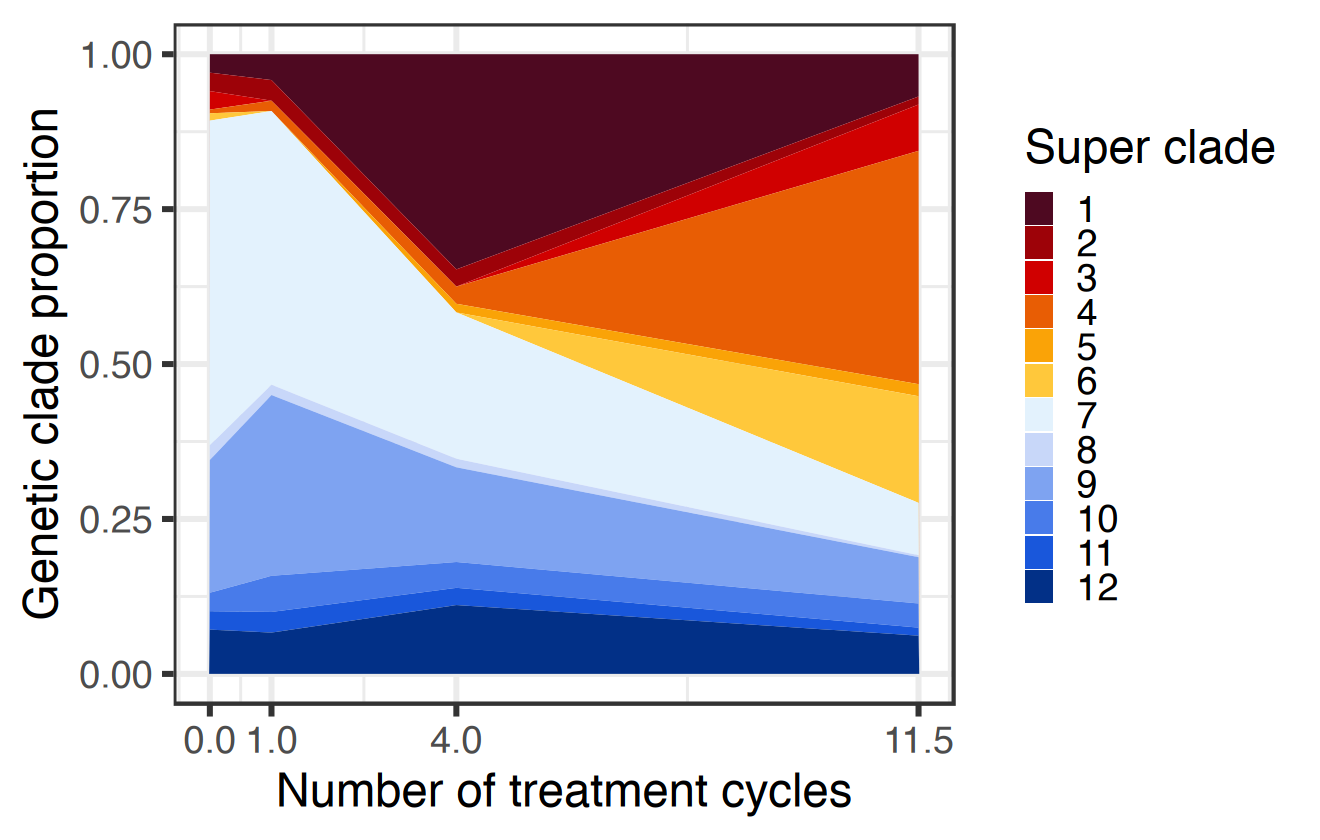

In [16]:
# Load the table outlining the genetic clades
clades <- data.frame(read_csv("../Data/CNA_Data/Processed/Genetic_Clades_And_SuperClades.csv",
                              col_types = "ccc"))
# Set rownames for easy sorting
rownames(clades) <- clades$Cell_id

# Define the time point corresponding to each cell
t <- c()
t[grep("POT",clades$Cell_id)] <- 0
t[grep("DSIb|DSIa",clades$Cell_id)] <- 1
t[grep("DSIV",clades$Cell_id)] <- 4
t[grep("DT1_P1",clades$Cell_id)] <- 11.5

# Define the sample (and replicate) corresponding to each cell
sample <- c()
sample[grep("POTm",clades$Cell_id)] <- "T0.A"
sample[grep("POTp",clades$Cell_id)] <- "T0.B"
sample[grep("DSIa",clades$Cell_id)] <- "T1.A"
sample[grep("DSIb",clades$Cell_id)] <- "T1.B"
sample[grep("DSIVa",clades$Cell_id)] <- "T4.A"
sample[grep("DSIVb",clades$Cell_id)] <- "T4.B"
sample[grep("DT1_P1a",clades$Cell_id)] <- "T11.A"
sample[grep("DT1_P1b",clades$Cell_id)] <- "T12.B"
sample <- factor(sample,levels = c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))

clades <- clades %>% dplyr::mutate(Time = t) %>%
                     dplyr::mutate(Sample = sample) 


table <- proportions(data = clades,obj = "SuperClade",cat = "Time", subset = F, sub_group = F, sub_level = F)
table$SuperClade <- factor(table$SuperClade,levels = sprintf("%s",1:12))

# plot the genetic clade proportions over time
options(repr.plot.width=11, repr.plot.height=7)
p <- ggplot(table, aes(fill = SuperClade, x = as.numeric(Time), y = Proportion))+
  geom_area(alpha=1) +
  scale_fill_manual(name = "Super clade",
                    values = c("1" = "#4e0921",
                               "2" = "#9d0208",
                               "3" = "#d00000",
                               "4" = "#e85d04",
                               "5" = "#faa307",
                               "6" = "#ffc83b",
                               "7" = "#e3f2fd",
                               "8" = "#c8d7f9",
                               "9" = "#7ea3f1",
                               "10" = "#487bea",
                               "11" = "#1957db",
                               "12" = "#023087")) +
  scale_x_continuous(name = "Number of treatment cycles",breaks = c(0,1,4,11.5))+
  xlab("Number of treatment cycles") +
  ylab("Genetic clade proportion") +
  theme_bw(base_size = 28)
p


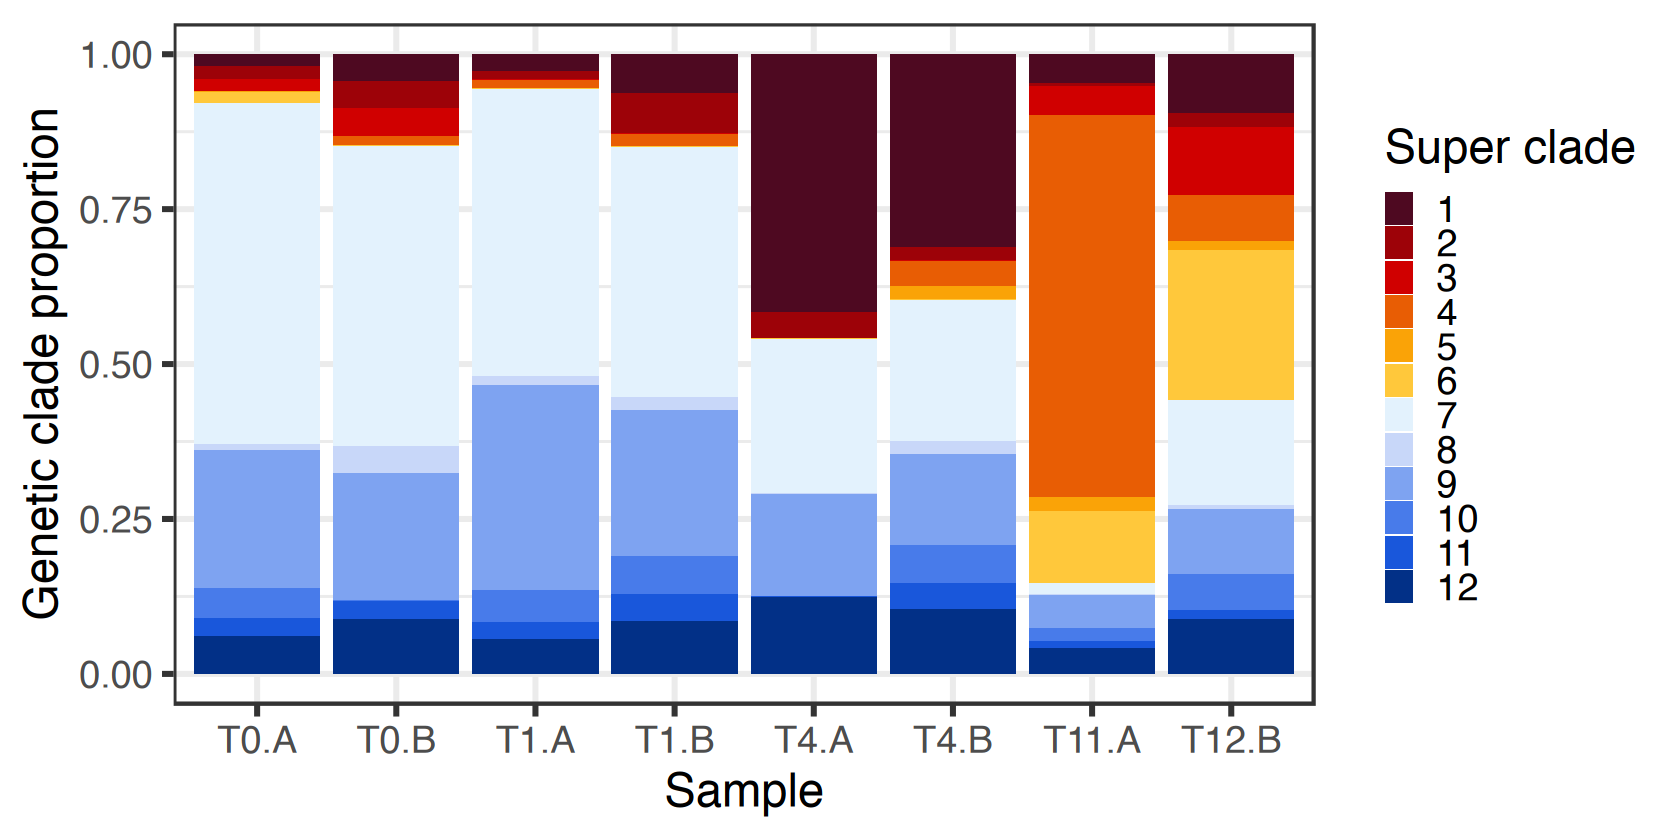

In [20]:
table <- proportions(data = clades,obj = "SuperClade",cat = "Sample", subset = F, sub_group = F, sub_level = F)

# Set the ordering of the sample
table$SuperClade <- factor(table$SuperClade,levels = sprintf("%s",1:12))
table$Sample <- factor(table$Sample,levels =   c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))

# Make sure the proportions are numeric
table$Proportion <- as.numeric(table$Proportion)

# Plot the genetic clade proportions over samples
options(repr.plot.width=14, repr.plot.height=7)
p <- ggplot(table, aes(fill = SuperClade, x = Sample, y = Proportion))+
  geom_bar(position = "fill", stat="identity") +
   scale_fill_manual(name = "Super clade",
                    values = c("1" = "#4e0921",
                               "2" = "#9d0208",
                               "3" = "#d00000",
                               "4" = "#e85d04",
                               "5" = "#faa307",
                               "6" = "#ffc83b",
                               "7" = "#e3f2fd",
                               "8" = "#c8d7f9",
                               "9" = "#7ea3f1",
                               "10" = "#487bea",
                               "11" = "#1957db",
                               "12" = "#023087")) +
  xlab("Sample") +
  ylab("Genetic clade proportion") +
  theme_bw(base_size = 28)
p


## Visualising the pathway z-score heatmap and defining epigenetic classes

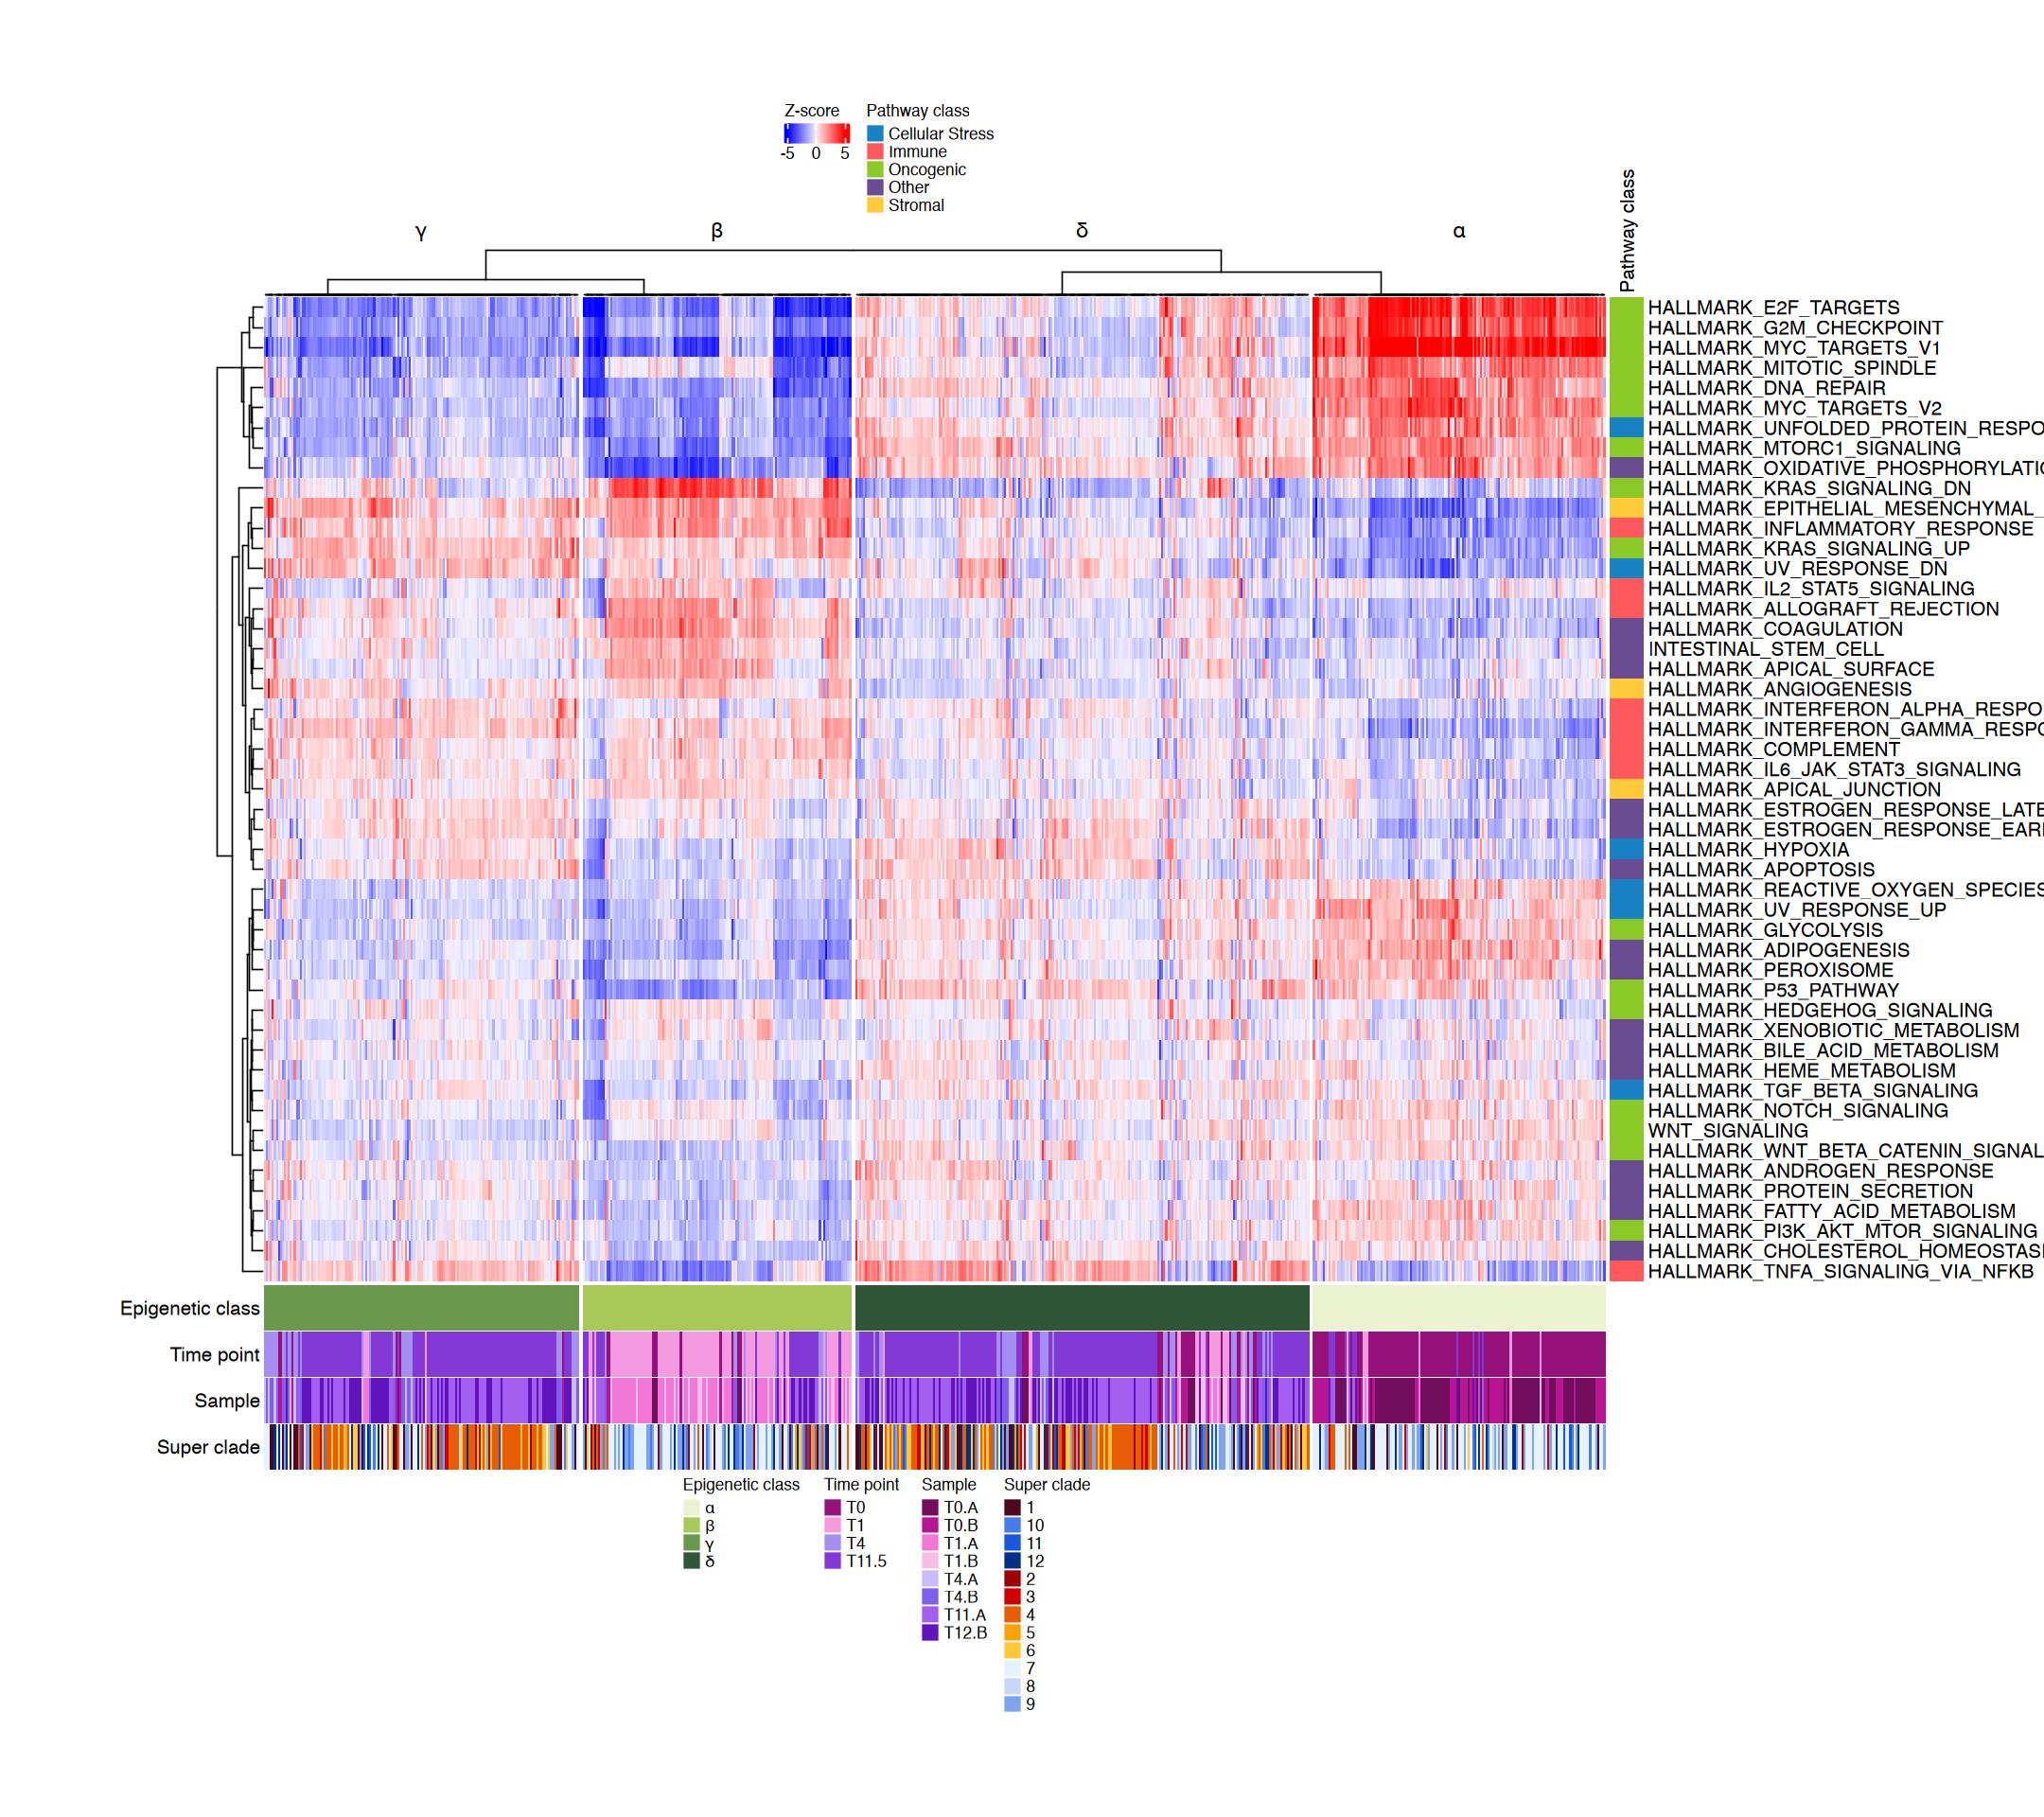

In [26]:
# Load and format the GSVA pathway z-score matrix 
gsva <- data.frame(read_csv("../Data/ATAC_Data/GeneExpressionScores/DATAC/DATAC_Consensus_HallmarkPathwayScores.csv",
                           col_types = paste("c",rep("d",49), sep = "")))
rownames(gsva) <- gsva[,1]
gsva <- data.frame(gsva[,-1])

data <- as.matrix(t(gsva))
pathways <-  str_replace(rownames(data),"HALLMARK_","")

# Load epigenetic classes
epi_classes_df <- data.frame(read_csv("../Data/ATAC_Data/GeneExpressionScores/DATAC/DATAC_Consensus_EpigeneticClasses_C4.csv",
                                     col_types = "ccd"))
epi_class_names <- epi_classes_df$Cell_id

# Define the time point for each cell in 'epi_class_names'
time <- c()
time[grep("POT",epi_class_names)] <- "T0"
time[grep("DSIb|DSIa",epi_class_names)] <- "T1"
time[grep("DSIV",epi_class_names)] <- "T4"
time[grep("DT1_P1",epi_class_names)] <- "T11.5"

time <- factor(time,levels = c("T0","T1","T4","T11.5"))

# Define the sample for each cell in 'epi_class_names'
# Define the sample for each cell in 'epi_class_names'
sample <- c()
sample[grep("POTa|POTm",epi_class_names)] <- "T0.A"
sample[grep("POTb|POTp",epi_class_names)] <- "T0.B"
sample[grep("DSIa",epi_class_names)] <- "T1.A"
sample[grep("DSIb",epi_class_names)] <- "T1.B"
sample[grep("DSIVa",epi_class_names)] <- "T4.A"
sample[grep("DSIVb",epi_class_names)] <- "T4.B"
sample[grep("DT1_P1a",epi_class_names)] <- "T11.A"
sample[grep("DT1_P1b",epi_class_names)] <- "T12.B"

sample <- factor(sample,levels = c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))

# Define the clade for each cell in 'epi_class_names'
clade <- clades[epi_class_names,]$SuperClade

# Define column annotations
column_annotation <- data.frame(epi_classes_df$consensus_cluster,time,sample,clade)
colnames(column_annotation) <- c("Epigenetic class","Time point","Sample","Super clade")
rownames(column_annotation) <- epi_class_names



column_annotation_h <- ComplexHeatmap::HeatmapAnnotation(df = column_annotation,
                                                          col = list(`Epigenetic class` = c("\u03B1" = "#ebf2cf",
                                                                                             "\u03B2" = "#a7c957",
                                                                                             "\u03B3" = "#6a994e",
                                                                                             "\u03B4" = "#2f5637"),
                                                                      `Sample` = c("T0.A" = "#730d5d",
                                                                                   "T0.B" = "#b81595",
                                                                                   "T1.A" =  "#f077d6",
                                                                                   "T1.B" =  "#f8bceb",
                                                                                   "T4.A" = "#c9bcf8",
                                                                                   "T4.B" = "#7e60ef",
                                                                                   "T11.A"= "#a25fef",
                                                                                   "T12.B"= "#6113bc"),
                                                                      `Time point` =  c("T0" = "#961179",
                                                                                  "T1" =  "#F49AE1",
                                                                                  "T4" = "#A48EF4",
                                                                                  "T11.5"= "#8239D6"),
                                                                      `Super clade` = c("1" = "#4e0921",
                                                                                       "2" = "#9d0208",
                                                                                       "3" = "#d00000",
                                                                                       "4" = "#e85d04",
                                                                                       "5" = "#faa307",
                                                                                       "6" = "#ffc83b",
                                                                                       "7" = "#e3f2fd",
                                                                                       "8" = "#c8d7f9",
                                                                                       "9" = "#7ea3f1",
                                                                                       "10" = "#487bea",
                                                                                       "11" = "#1957db",
                                                                                       "12" = "#023087")),
                                                                      annotation_legend_param = list(
                                                                         `Epigenetic class` = list(legend_direction = "horizontal"),
                                                                          `Time point`= list(legend_direction = "horizontal"),
                                                                          `Sample`= list(legend_direction = "horizontal"),
                                                                          `Super clade`= list(legend_direction = "horizontal")
                                                                      ),
                                                                      simple_anno_size = unit(1, "cm"),
                                                                      annotation_name_side = "left")



# Define row annotations
class_h <- c("Other","Immune","Other",
             "Stromal","Stromal","Other",
             "Other","Other","Other",
             "Other","Immune","Oncogenic",
             "Oncogenic","Stromal","Other",
             "Other","Other","Oncogenic",
             "Oncogenic","Oncogenic","Other",
             "Cellular Stress","Immune","Immune",
             "Immune","Immune","Immune",
             "Oncogenic","Oncogenic","Oncogenic",
             "Oncogenic","Oncogenic","Oncogenic",
             "Oncogenic","Other","Oncogenic",
             "Other","Oncogenic","Other",
             "Cellular Stress","Cellular Stress","Immune",
             "Cellular Stress","Cellular Stress","Cellular Stress",
             "Oncogenic","Other","Oncogenic","Other"
)

row_annotation <- data.frame(class_h)
rownames(row_annotation) <- sprintf("%s",1:nrow(data))
colnames(row_annotation) <- c("Pathway class")

row_annotation_h <- ComplexHeatmap::rowAnnotation(df = row_annotation,
                                                  col = list(`Pathway class` = c("Immune" = "#ff595e",
                                                                                 "Stromal" = "#ffca3a",
                                                                                 "Oncogenic" = "#8ac926",
                                                                                 "Cellular Stress" = "#1982c4",
                                                                                 "Other" = "#6a4c93") ),
                                                  simple_anno_size = unit(0.75, "cm"),
                                                  annotation_name_side = "top")



# Define the heatmap colours
paletteLength <-20
myColor <- colorRampPalette(c("blue", "white", "red"))(paletteLength)
myBreaks <- c(seq(-5, 0, length.out=ceiling(paletteLength/2)), 
              seq(0, 5, length.out=floor(paletteLength/2)))

colours <- circlize::colorRamp2(myBreaks,myColor) 

# Define the heatmap
dend <- ComplexHeatmap::cluster_within_group(data,epi_classes_df$consensus_cluster)

h <- ComplexHeatmap::Heatmap(data, col = colours,
                             show_column_names = FALSE,
                             bottom_annotation = column_annotation_h,
                             right_annotation = row_annotation_h,
                             cluster_columns = dend,
                             column_split = 4,
                             heatmap_legend_param = list(title = "Z-score",legend_direction = "horizontal"),
                             width = unit(30,"cm"),
                             height = unit(22,"cm"))

options(repr.plot.width=18, repr.plot.height=16)

# Draw the heatmap
suppressWarnings({
  draw(h, heatmap_legend_side = "top", annotation_legend_side = "bottom")
})



## Studying epigenetic class evolution over time and across replicates

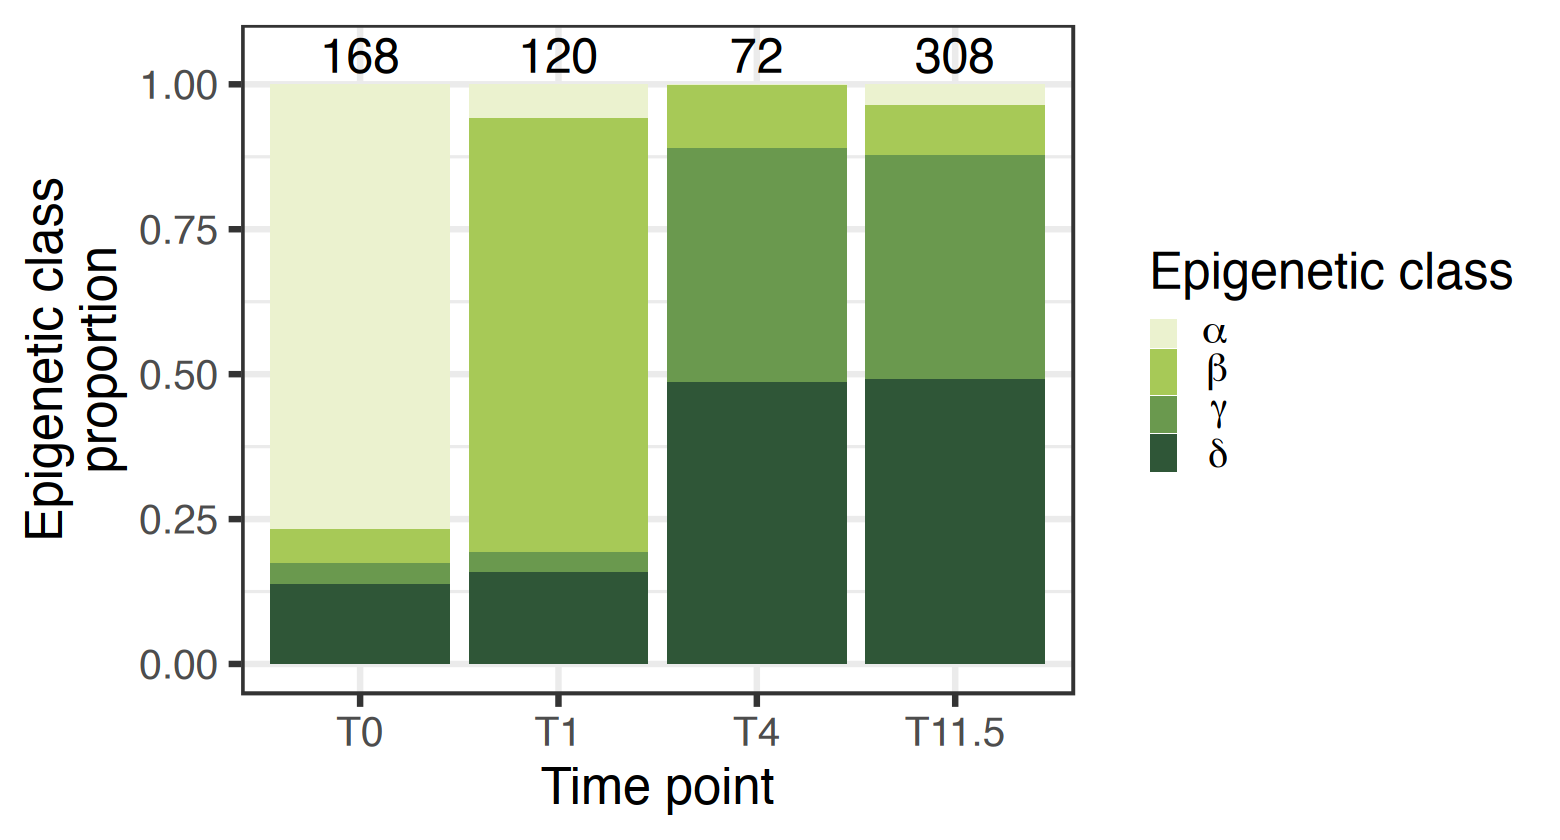

In [64]:
# Load epigenetic classes
epi_classes <- data.frame(read_csv("../Data/ATAC_Data/GeneExpressionScores/DATAC/DATAC_Consensus_EpigeneticClasses_C4.csv",
                                     col_types = "ccd"))

# Define the time point for each cell in 'epi_class_names'
time <- c()
time[grep("POT",epi_classes$Cell_id)] <- "T0"
time[grep("DSIb|DSIa",epi_classes$Cell_id)] <- "T1"
time[grep("DSIV",epi_classes$Cell_id)] <- "T4"
time[grep("DT1_P1",epi_classes$Cell_id)] <- "T11.5"

time <- factor(time,levels = c("T0","T1","T4","T11.5"))

# Define the sample for each cell in 'epi_class_names'
sample <- c()
sample[grep("POTm|POTa",epi_classes$Cell_id)] <- "T0.A"
sample[grep("POTp|POTb",epi_classes$Cell_id)] <- "T0.B"
sample[grep("DSIa",epi_classes$Cell_id)] <- "T1.A"
sample[grep("DSIb",epi_classes$Cell_id)] <- "T1.B"
sample[grep("DSIVa",epi_classes$Cell_id)] <- "T4.A"
sample[grep("DSIVb",epi_classes$Cell_id)] <- "T4.B"
sample[grep("DT1_P1a",epi_classes$Cell_id)] <- "T11.A"
sample[grep("DT1_P1b",epi_classes$Cell_id)] <- "T12.B"

sample <- factor(sample,levels = c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))

# Combine classifications into a dataframe
data_plot <- data.frame("cell_id" = epi_classes$Cell_id,
                        "time" = time,
                        "sample" = sample,
                        "epi_class" = epi_classes$consensus_cluster,
                        "clade" = clades[epi_classes$Cell_id,]$SuperClade)

# Obtain epigenetic class proportions per time
table <- proportions(data = data_plot,obj = "epi_class",cat = "time", subset = FALSE, sub_group = NA, sub_level = NA)


table$time <- factor(table$time,levels = c("T0","T1","T4","T11.5"))

counts <- data.frame(table(data_plot$time))
colnames(counts)[1] <- "time"

# Plot epigenetic class proportions per time
options(repr.plot.width=13, repr.plot.height=7)

p <- ggplot(table, aes(fill = epi_class, x =time, y = Proportion))+
  geom_bar(position = "fill", stat="identity") +
  scale_fill_manual(name = "Epigenetic class",
                    values = c("α" = "#ebf2cf",
                               "β" = "#a7c957",
                               "γ" = "#6a994e",
                               "δ" = "#2f5637"),
                    labels = c("α" = expression(alpha), "β" = expression(beta),
                               "γ" = expression(gamma),"δ" =expression(delta))) +
  geom_text(data = counts,
            aes(x =`time`, y = 1.05, label = Freq),
            inherit.aes = F,# slightly above the bar
            size = 10
  ) +
  xlab("Time point")+
  ylab(str_wrap("Epigenetic class proportion", width = 20))+
  theme_bw(base_size = 30)
p

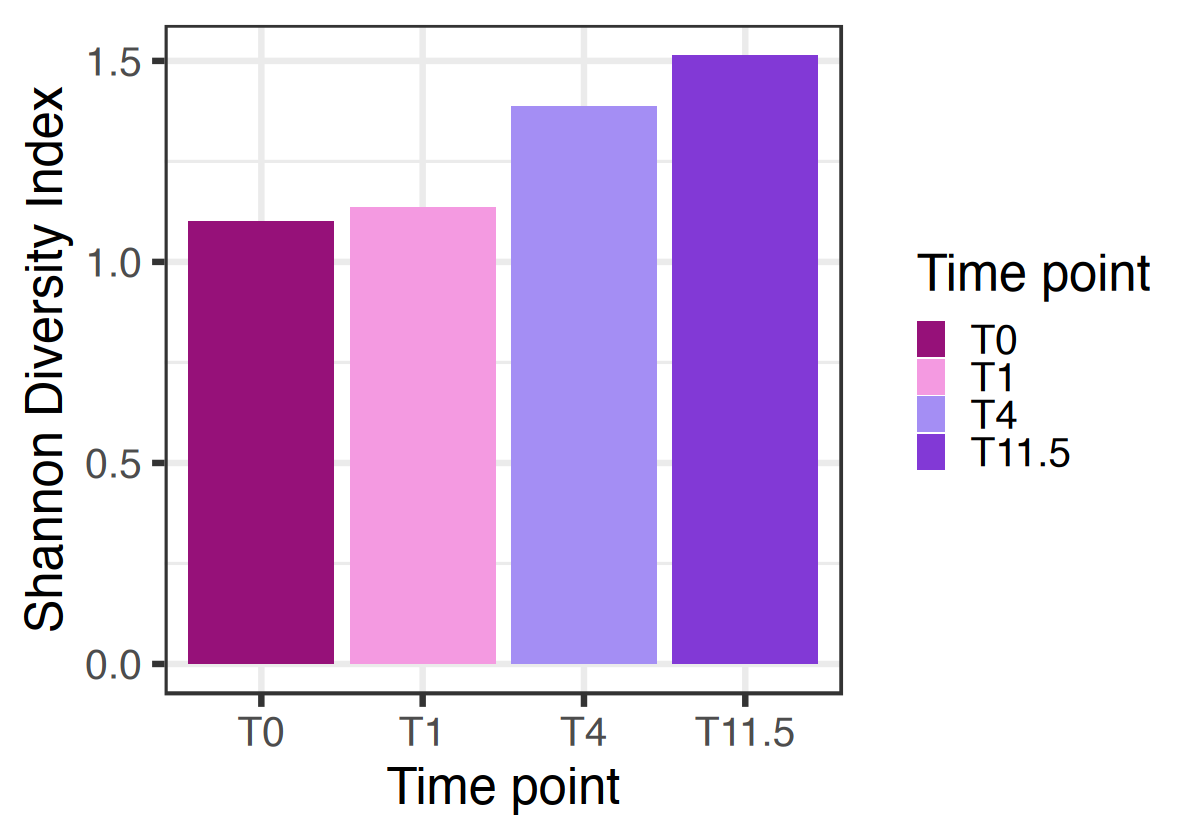

In [65]:
# Compute the Shannon Diversity Index at each time point

shannon_div_t <- c()
for (t in unique(table$time)){
  shannon_div_t <- c(shannon_div_t,diversity(table[table$time == t,]$Proportion, 
                                             index = "shannon",
                                             base = 2)) 
}

shannon_div_t <- data.frame(unique(table$time),
                            shannon_div_t)
colnames(shannon_div_t) <- c("Time","Shannon Diversity Index")
shannon_div_t$Time <- factor(shannon_div_t$Time, levels =  c("T0","T1","T4","T11.5"))

options(repr.plot.width=10, repr.plot.height=7)

p <- ggplot(shannon_div_t, aes(fill = `Time`, x = `Time`, y = `Shannon Diversity Index`))+
  scale_fill_manual(name = "Time point",
                    values = c("T0" = "#961179",
                               "T1" =  "#F49AE1",
                               "T4" = "#A48EF4",
                               "T11.5"= "#8239D6")) +
  geom_bar(stat = "identity") +
  xlab("Time point") +
  #guides(fill = "none", color = "none")+
  #coord_cartesian(ylim = c(0,2))+
  theme_bw(base_size = 30)

p

In [47]:
# Table of the number of cells in each epigenetic class at each time point
table <- abundances(data = data_plot,obj = "epi_class",cat = "time", subset = FALSE, sub_group = NA, sub_level = NA)


# Transform 'table' to obtain columns of abundances for each time point
table_mod  <- table %>% tidyr::pivot_wider(names_from = time, values_from = Abundance) %>%
  dplyr::select(- epi_class)
table_mod <- table_mod[,c("T0","T1","T4","T11.5")]


# Perform the pairwise Hutcheson t-tests
t <- multiple_Hutcheson_t_test(table_mod, shannon.base = 2)

# Print the p-values
t$p.values

,T0 H = 1.1,T1 H = 1.13,T4 H = 1.39,T11.5 H = 1.51
T0 H = 1.1,NA,0.41177,0.01362,0.00024
T1 H = 1.13,0.41177,NA,0.03949,0.00226
T4 H = 1.39,0.01362,0.03949,NA,0.08521
T11.5 H = 1.51,0.00024,0.00226,0.08521,NA


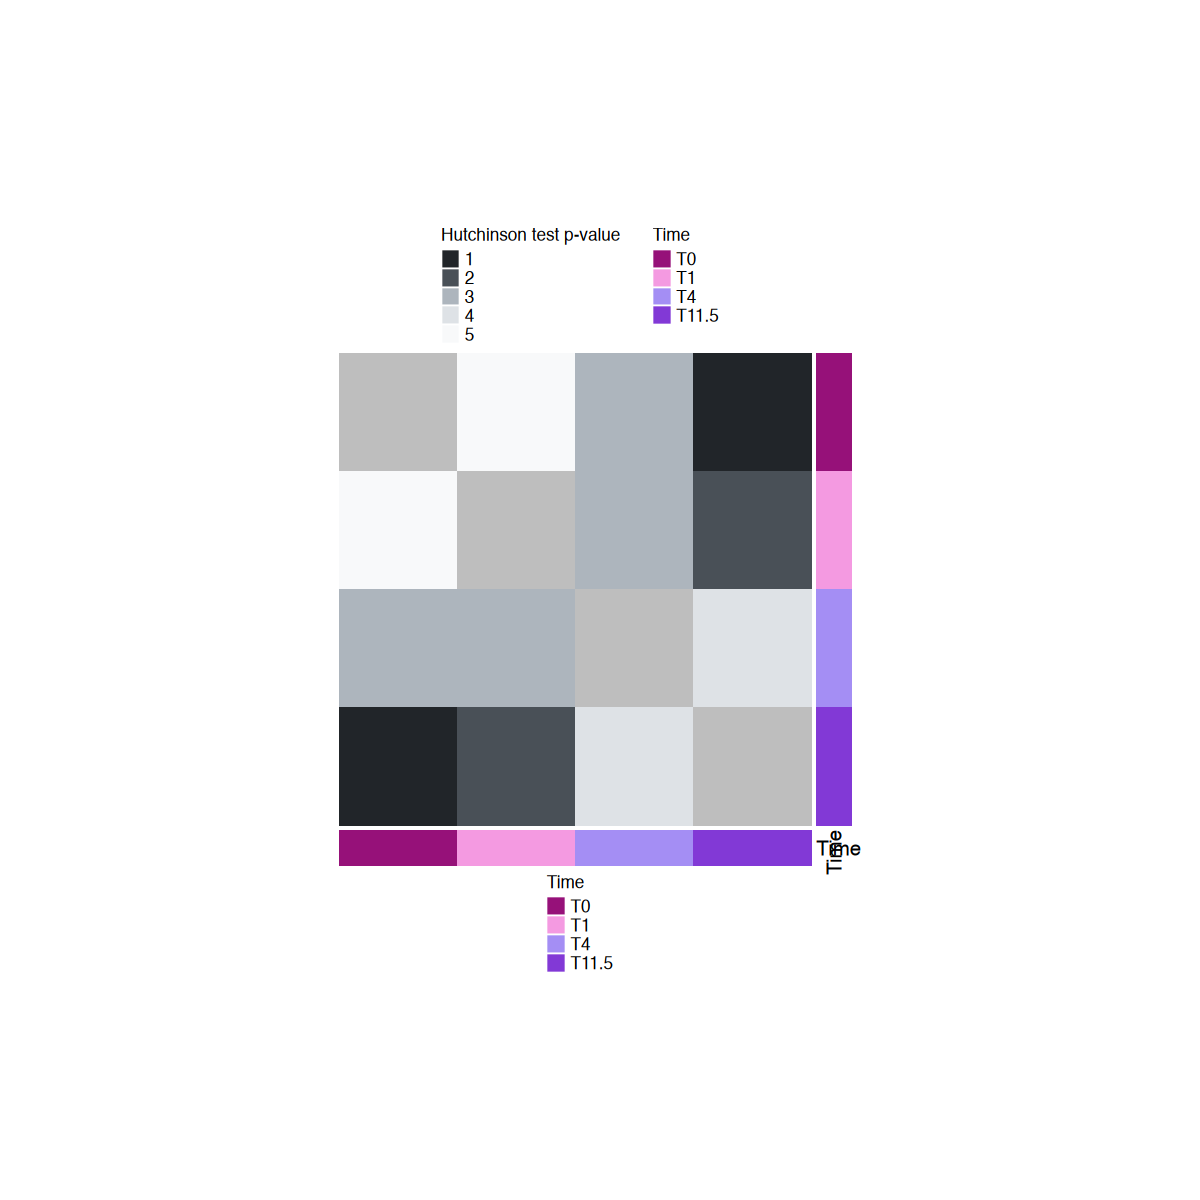

In [50]:
# heatmap of p values
row_annotation <- data.frame(unlist(str_split(colnames(t$p.values)," "))[seq(1,4*4,4)])
rownames(row_annotation) <- rownames(t$p.values)
colnames(row_annotation) <- c("Time")
row_annotation$Time <- factor(row_annotation$Time, levels = c("T0","T1","T4","T11.5"))

row_annotation_h <- ComplexHeatmap::rowAnnotation(df = row_annotation,
                                                  col = list(`Time` = c("T0" = "#961179",
                                                                              "T1" =  "#F49AE1",
                                                                              "T4" = "#A48EF4",
                                                                              "T11.5"= "#8239D6")),
                                                  simple_anno_size = unit(0.75, "cm"),
                                                  annotation_name_side = "bottom")


column_annotation_h <- ComplexHeatmap::HeatmapAnnotation(df = row_annotation,
                                                         col = list(`Time` = c("T0" = "#961179",
                                                                                     "T1" =  "#F49AE1",
                                                                                     "T4" = "#A48EF4",
                                                                                     "T11.5"= "#8239D6")),
                                                         simple_anno_size = unit(0.75, "cm"),
                                                         annotation_name_side = "right")

new_t <- t$p.values
new_t[t$p.values < 0.001] <- 1
new_t[t$p.values >= 0.001 & t$p.values < 0.01] <- 2
new_t[t$p.values >= 0.01 & t$p.values < 0.05] <- 3
new_t[t$p.values >= 0.05 & t$p.values < 0.1] <- 4
new_t[t$p.values >= 0.1] <- 5

h <- ComplexHeatmap::Heatmap(new_t, col = c("1" = "#212529",
                                            "2" = "#495057",
                                            "3" = "#adb5bd",
                                            "4" = "#dee2e6",
                                            "5" = "#f8f9fa"),
                             show_column_names = FALSE,
                             show_row_names = FALSE,
                             cluster_rows = F,
                             cluster_columns  = F,
                             bottom_annotation = column_annotation_h,
                             right_annotation = row_annotation_h,  
                             heatmap_legend_param = list(title = "Hutchinson test p-value",legend_direction = "horizontal"),
                             width = unit(10,"cm"),
                             height = unit(10,"cm"))

suppressWarnings({
    options(repr.plot.width=10, repr.plot.height=10)
  draw(h, heatmap_legend_side = "top", annotation_legend_side = "bottom")
})

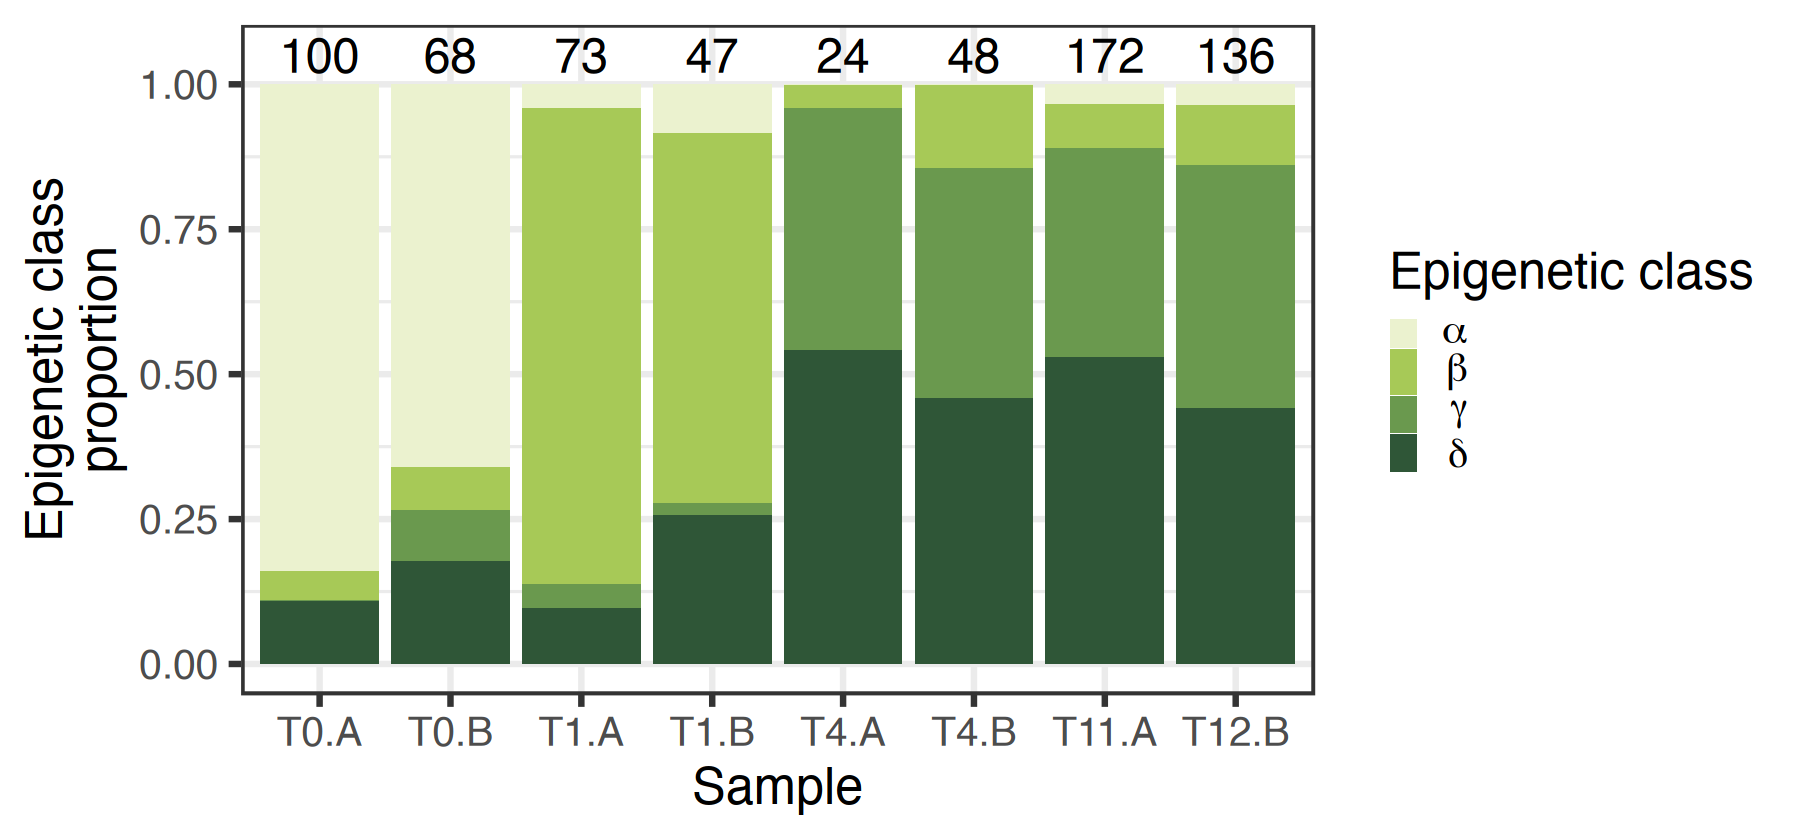

In [53]:
# Obtain epigenetic class proportions per sample
table <- proportions(data = data_plot,obj = "epi_class",cat = "sample", subset = FALSE, sub_group = NA, sub_level = NA)

# Format table cols
table$Proportion <- as.numeric(table$Proportion)
table$sample <- factor(table$sample,levels =   c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))


# Obtain counts per sample
counts <- data.frame(table(data_plot$sample))
colnames(counts)[1] <- "sample"

# Plot epigenetic class proportions per time
options(repr.plot.width=15, repr.plot.height=7)

p <- ggplot(table, aes(fill = epi_class, x =sample, y = Proportion))+
  geom_bar(position = "fill", stat="identity") +
  scale_fill_manual(name = "Epigenetic class",
                    values = c("α" = "#ebf2cf",
                               "β" = "#a7c957",
                               "γ" = "#6a994e",
                               "δ" = "#2f5637"),
                    labels = c("α" = expression(alpha), "β" = expression(beta),
                               "γ" = expression(gamma),"δ" =expression(delta))) +
  geom_text(data = counts,
            aes(x =`sample`, y = 1.05, label = Freq),
            inherit.aes = F,# slightly above the bar
            size = 10,
            fontface = "bold"
  ) +
  xlab("Sample")+
  ylab(str_wrap("Epigenetic class proportion", width = 20))+
  theme_bw(base_size = 30)
p


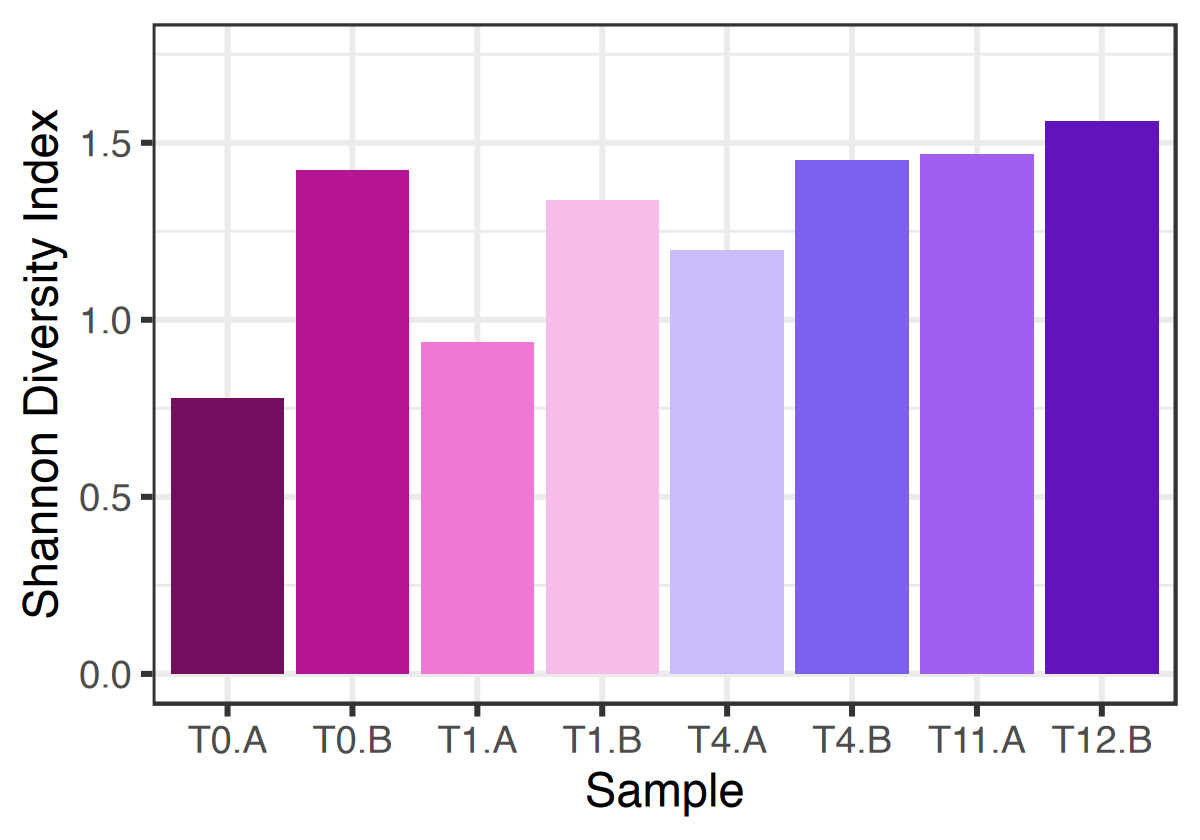

In [56]:
# Compute the Shannon diversity index for each sample
shannon_div <- c()
for (s in c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B")){
  shannon_div <- c(shannon_div,diversity(table[table$sample == s,]$Proportion, 
                                         index = "shannon",
                                         base = 2)) 
}

shannon_div <- data.frame(c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"),
                          c(shannon_div))
colnames(shannon_div) <- c("Sample","Shannon Diversity Index")
shannon_div$Sample <- factor(shannon_div$Sample, levels =  c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))

# Plot the Shannon diversity index for each sample
options(repr.plot.width=10, repr.plot.height=7)

p <- ggplot(shannon_div, aes(fill = Sample, x = Sample, y = `Shannon Diversity Index`))+
  scale_fill_manual(name = "Sample",
                    values = c("T0.A" = "#730d5d",
                               "T0.B" = "#b81595",
                               "T1.A" =  "#f077d6",
                               "T1.B" =  "#f8bceb",
                               "T4.A" = "#c9bcf8",
                               "T4.B" = "#7e60ef",
                               "T11.A"= "#a25fef",
                               "T12.B"= "#6113bc")) +
  geom_bar(stat = "identity") +
  xlab("Sample") +
  guides(fill = "none", color = "none")+
  coord_cartesian(ylim = c(0,1.75))+
  theme_bw(base_size = 28)

p

In [57]:
# Perform pairwise Hutcheson t-tests to test the significance of the differences between the Shannon diversity in different samples

# Table of the number of cells in each epigenetic class in each sample
table <- abundances(data = data_plot,obj = "epi_class",cat = "sample", subset = FALSE, sub_group = NA, sub_level = NA)


# Transform 'table' to obtain columns of abundances in each sample
table_mod  <- table %>% tidyr::pivot_wider(names_from = sample, values_from = Abundance) %>%
  dplyr::select(- epi_class)


# Perform the pairwise Hutcheson t-tests
t <- multiple_Hutcheson_t_test(table_mod, shannon.base = 2)

# Print the p-values
t$p.values

,T4.A H = 1.2,T4.B H = 1.45,T1.A H = 0.94,T1.B H = 1.34,T11.A H = 1.47,T12.B H = 1.56,T0.A H = 0.78,T0.B H = 1.42
T4.A H = 1.2,NA,0.07108,0.12331,0.26119,0.05616,0.01816,0.01691,0.14175
T4.B H = 1.45,0.07108,NA,0.00323,0.26468,0.43877,0.16237,0.00000,0.43222
T1.A H = 0.94,0.12331,0.00323,NA,0.04243,0.00219,0.00047,0.22357,0.01488
T1.B H = 1.34,0.26119,0.26468,0.04243,NA,0.23156,0.10656,0.00326,0.34815
T11.A H = 1.47,0.05616,0.43877,0.00219,0.23156,NA,0.19200,0.00000,0.39096
T12.B H = 1.56,0.01816,0.16237,0.00047,0.10656,0.19200,NA,0.00000,0.20176
T0.A H = 0.78,0.01691,0.00000,0.22357,0.00326,0.00000,0.00000,NA,0.00046
T0.B H = 1.42,0.14175,0.43222,0.01488,0.34815,0.39096,0.20176,0.00046,NA


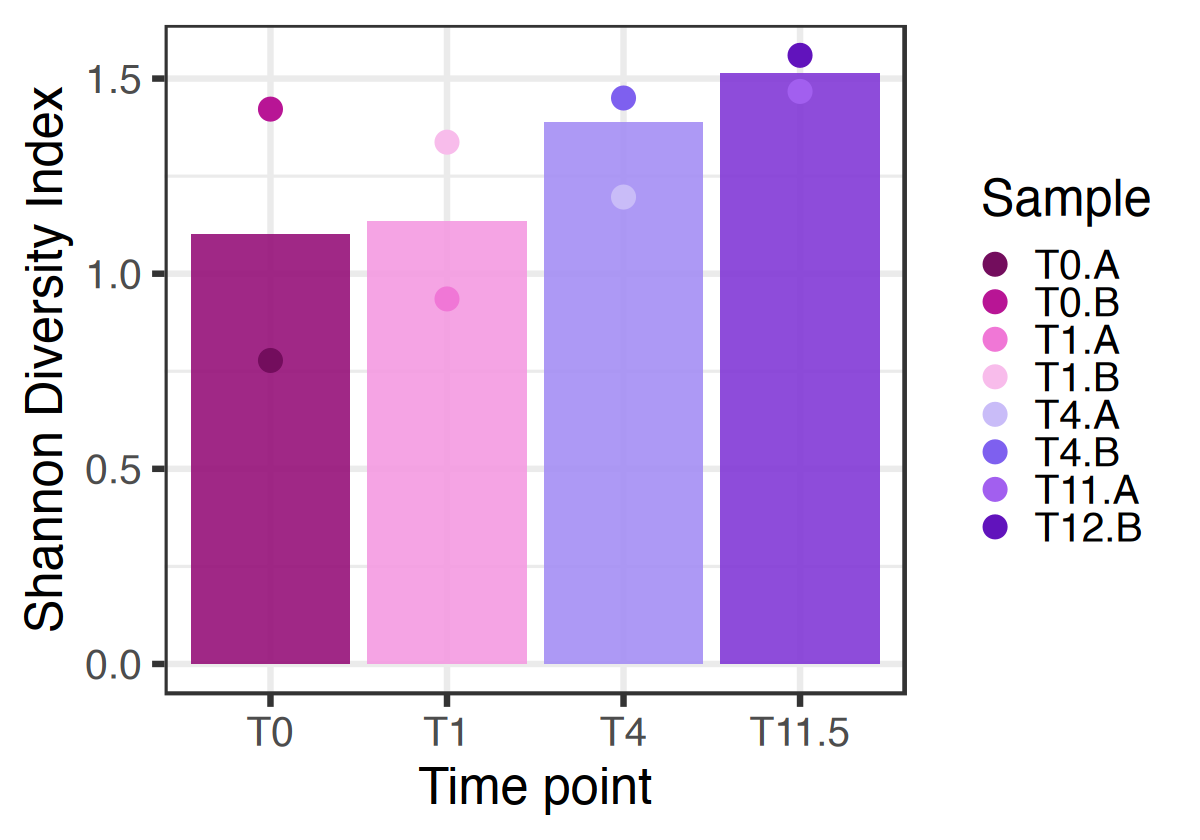

In [62]:
# Plot the Shannon diversity index per time point and sample on one graph

# Obtain epigenetic class proportions per time
table <- proportions(data = data_plot,obj = "epi_class",cat = "time", subset = FALSE, sub_group = NA, sub_level = NA)


table$time <- factor(table$time,levels = c("T0","T1","T4","T11.5"))

shannon_div_t <- c()
for (t in unique(table$time)){
  shannon_div_t <- c(shannon_div_t,diversity(table[table$time == t,]$Proportion, 
                                             index = "shannon",
                                             base = 2)) 
}

shannon_div_t <- data.frame(unique(table$time),
                            shannon_div_t)
colnames(shannon_div_t) <- c("Time","Shannon Diversity Index")
shannon_div_t$Time <- factor(shannon_div_t$Time, levels =  c("T0","T1","T4","T11.5"))

# Obtain epigenetic class proportions per sample
table <- proportions(data = data_plot,obj = "epi_class",cat = "sample", subset = FALSE, sub_group = NA, sub_level = NA)


table$sample <- factor(table$sample,levels = c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))
table$Proportion <- as.numeric(table$Proportion)


shannon_div <- c()
for (s in c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B")){
  shannon_div <- c(shannon_div,diversity(table[table$sample == s,]$Proportion, 
                                         index = "shannon",
                                         base = 2)) 
}

shannon_div <- data.frame(c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"),
                          c("T0","T0","T1","T1","T4","T4","T11.5","T11.5"),
                          shannon_div)

colnames(shannon_div) <- c("Sample","Time","Shannon Diversity Index")
shannon_div$Time <- factor(shannon_div$Time, levels =  c("T0","T1","T4","T11.5"))
shannon_div$Sample <- factor(shannon_div$Sample, levels =  c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))

options(repr.plot.width=10, repr.plot.height=7)

p <- ggplot()+
  scale_fill_manual(name = "Time point",
                    values =   c("T0" = "#961179",
                                 "T1" =  "#F49AE1",
                                 "T4" = "#A48EF4",
                                 "T11.5"= "#8239D6")) +
  geom_bar(data = shannon_div_t, aes(fill = Time, x = Time, y = `Shannon Diversity Index`), stat = "identity", alpha = 0.9) +
  scale_color_manual(name = "Sample",
                     values = c("T0.A" = "#730d5d",
                                "T0.B" = "#b81595",
                                "T1.A" =  "#f077d6",
                                "T1.B" =  "#f8bceb",
                                "T4.A" = "#c9bcf8",
                                "T4.B" = "#7e60ef",
                                "T11.A"= "#a25fef",
                                "T12.B"= "#6113bc")) +
  geom_point(data = shannon_div, aes(color = Sample, x = Time, y = `Shannon Diversity Index`), size = 6)+
  xlab("Time point") +
  guides(fill = "none")+
  #coord_cartesian(ylim = c(0,2.25))+
  theme_bw(base_size = 30)

p



## Studying the co-evolution of the genetic clades and epigenetic classes

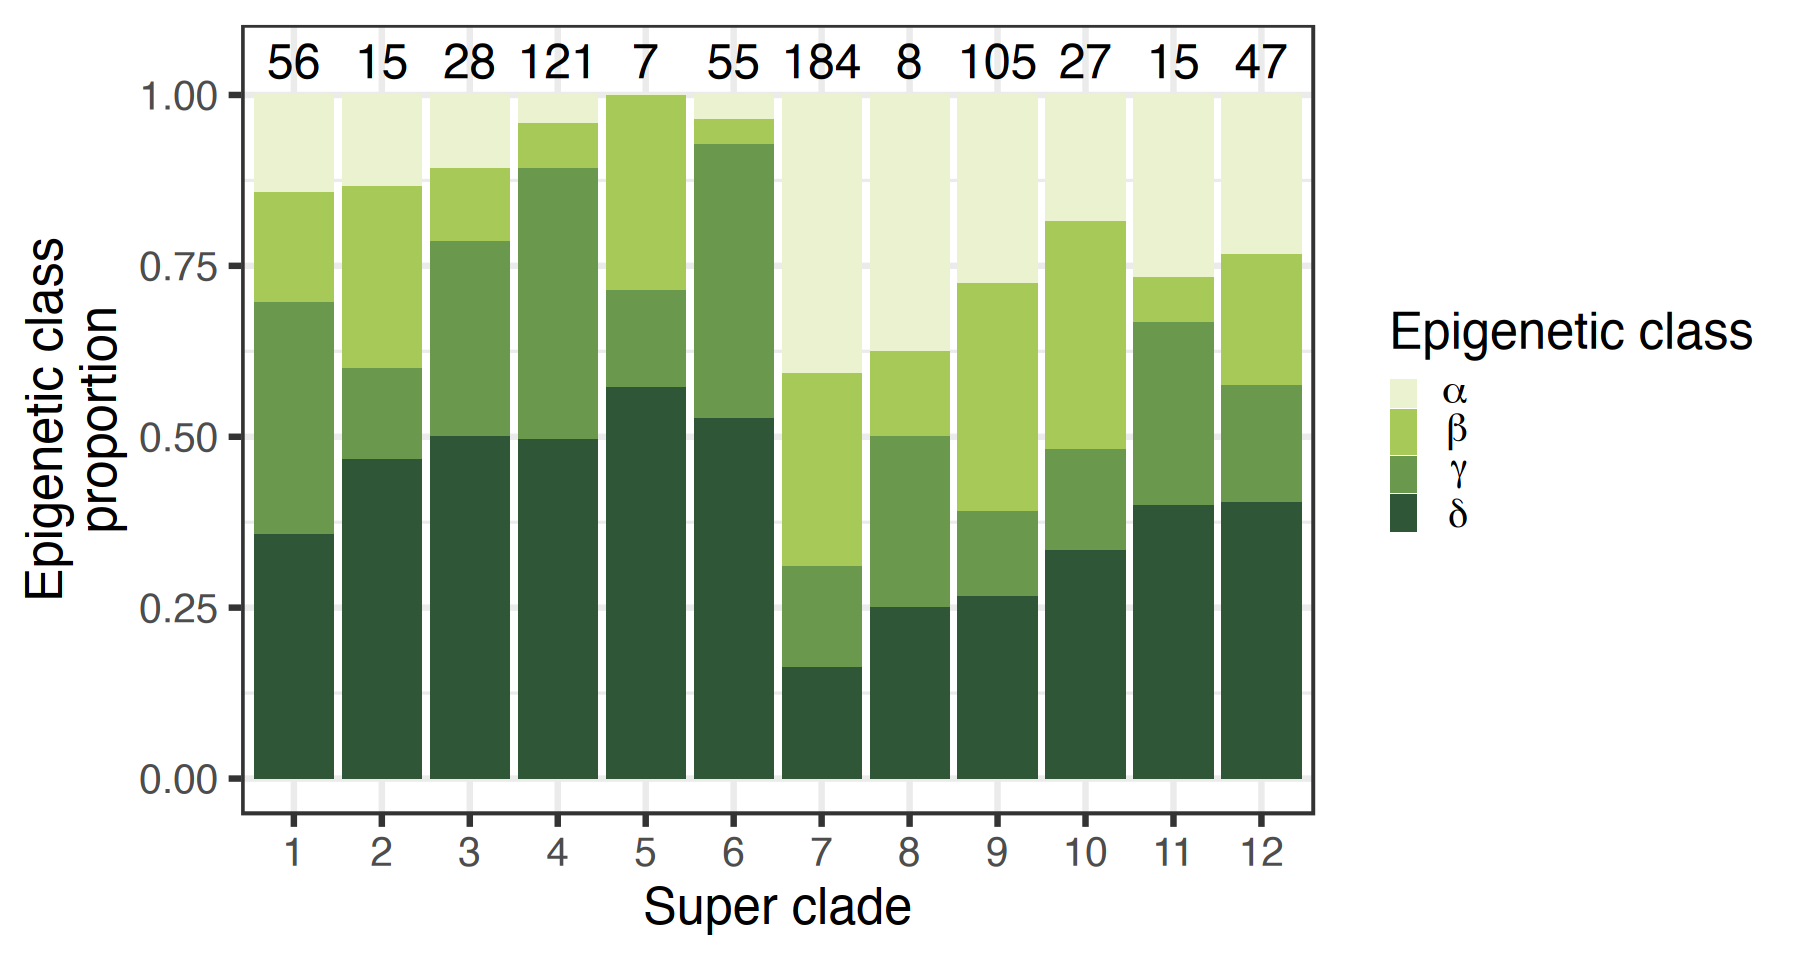

In [72]:
# Load epigenetic classes
epi_classes_df <- data.frame(read_csv("../Data/ATAC_Data/GeneExpressionScores/DATAC/DATAC_Consensus_EpigeneticClasses_C4.csv",
                                     col_types = "ccd"))

# Load genetic clades
clades <- data.frame(read_csv("../Data/CNA_Data/Processed/Genetic_Clades_And_SuperClades.csv",
                              col_types = "ccc"))
# Set rownames for easy sorting
rownames(clades) <- clades$Cell_id

time <- c()
time[grep("POT",epi_classes$Cell_id)] <- "T0"
time[grep("DSIb|DSIa",epi_classes$Cell_id)] <- "T1"
time[grep("DSIV",epi_classes$Cell_id)] <- "T4"
time[grep("DT1_P1",epi_classes$Cell_id)] <- "T11.5"

time <- factor(time,levels = c("T0","T1","T4","T11.5"))

sample <- c()
sample[grep("POTm|POTa",epi_classes$Cell_id)] <- "T0.A"
sample[grep("POTp|POTb",epi_classes$Cell_id)] <- "T0.B"
sample[grep("DSIa",epi_classes$Cell_id)] <- "T1.A"
sample[grep("DSIb",epi_classes$Cell_id)] <- "T1.B"
sample[grep("DSIVa",epi_classes$Cell_id)] <- "T4.A"
sample[grep("DSIVb",epi_classes$Cell_id)] <- "T4.B"
sample[grep("DT1_P1a",epi_classes$Cell_id)] <- "T11.A"
sample[grep("DT1_P1b",epi_classes$Cell_id)] <- "T12.B"

sample <- factor(sample,levels = c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))

data_plot <- data.frame("cell_id" = epi_classes$Cell_id,
                        "time" = time,
                        "sample" = sample,
                        "epi_class" = epi_classes$consensus_cluster,
                        "clade" = clades[epi_classes$Cell_id,]$SuperClade)

# Obtain epigenetic class proportions per genetic clade
table <- proportions(data = data_plot,obj = "epi_class",cat = "clade", subset = FALSE, sub_group = NA, sub_level = NA)

# Counts in each clade
counts <- data.frame(table(data_plot$clade))
colnames(counts)[1] <- "clade"


# Plot epigenetic class proportions per genetic clade
options(repr.plot.width=15, repr.plot.height=8)

# Format cols
table$clade <- factor(table$clade, levels = sprintf("%s",1:12))
counts$clade <- factor(counts$clade, levels = sprintf("%s",1:12))

p <- ggplot(table, aes(fill = epi_class, x =clade, y = Proportion))+
  geom_bar(position = "fill", stat="identity") +
  scale_fill_manual(name = "Epigenetic class",
                    values = c("α" = "#ebf2cf",
                               "β" = "#a7c957",
                               "γ" = "#6a994e",
                               "δ" = "#2f5637"),
                    labels = c("α" = expression(alpha), "β" = expression(beta),
                               "γ" = expression(gamma),"δ" =expression(delta))) +
  geom_text(data = counts,
            aes(x =`clade`, y = 1.05, label = Freq),
            inherit.aes = F,# slightly above the bar
            size = 10,
            fontface = "bold"
  ) +
  xlab("Super clade")+
  ylab(str_wrap("Epigenetic class proportion", width = 20))+
  theme_bw(base_size = 30)
p


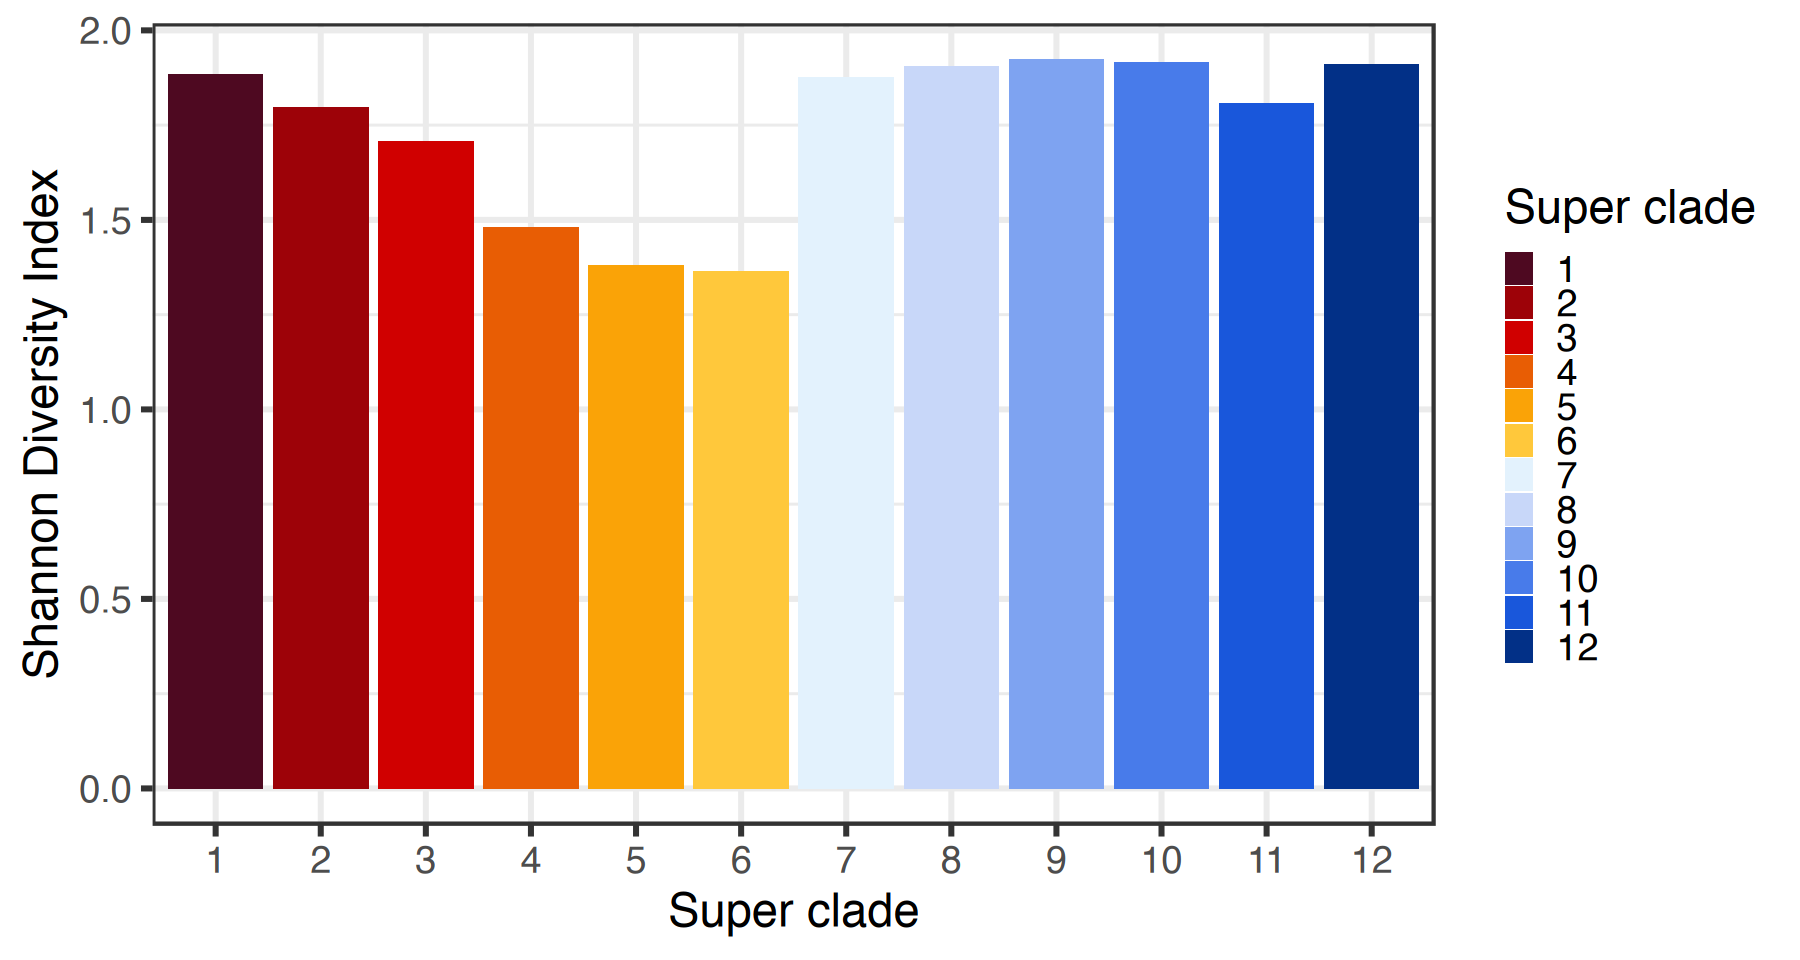

In [75]:
# Compute the Shannon diversity index for each clade
shannon_div <- c()
for (c in sprintf("%s",1:12)){
  shannon_div <- c(shannon_div,diversity(table[table$clade == c,]$Proportion, 
                                         index = "shannon",
                                         base = 2)) 
}

shannon_div <- data.frame(sprintf("%s",1:12),
                          shannon_div)
colnames(shannon_div) <- c("Super clade","Shannon Diversity Index")
shannon_div$`Super clade` <- factor(shannon_div$`Super clade`, levels =  sprintf("%s",1:12))

# Plot the Shannon diversity index for each clade
options(repr.plot.width=15, repr.plot.height=8)

p <- ggplot(shannon_div, aes(fill = `Super clade`, x = `Super clade`, y = `Shannon Diversity Index`))+
  scale_fill_manual(name = "Super clade",
                    values = c("1" = "#4e0921",
                               "2" = "#9d0208",
                               "3" = "#d00000",
                               "4" = "#e85d04",
                               "5" = "#faa307",
                               "6" = "#ffc83b",
                               "7" = "#e3f2fd",
                               "8" = "#c8d7f9",
                               "9" = "#7ea3f1",
                               "10" = "#487bea",
                               "11" = "#1957db",
                               "12" = "#023087")) +
  geom_bar(stat = "identity") +
  xlab("Super clade") +
  #guides(fill = "none", color = "none")+
  #coord_cartesian(ylim = c(0,2.5))+
  theme_bw(base_size = 28)

p

In [76]:
# Perform pairwise Hutcheson t-tests to test the significance of the differences between the Shannon diversity in each genetic clade

# Table of the number of cells in each epigenetic class in each genetic clade
table <- abundances(data = data_plot,obj = "epi_class",cat = "clade", subset = FALSE, sub_group = NA, sub_level = NA)

table$clade <- factor(table$clade, sprintf("%s",1:12))

# Transform 'table' to obtain columns of abundances in each genetic clade
table_mod  <- table %>% tidyr::pivot_wider(names_from = clade, values_from = Abundance) %>%
  dplyr::select(- epi_class)
table_mod <- table_mod[,sprintf("%s",1:12)]

# Perform the pairwise Hutcheson t-tests
t <- multiple_Hutcheson_t_test(table_mod, shannon.base = 2)

# Print the p-values
t$p.values

,1 H = 1.88,2 H = 1.8,3 H = 1.71,4 H = 1.48,5 H = 1.38,6 H = 1.36,7 H = 1.88,8 H = 1.91,9 H = 1.92,10 H = 1.92,11 H = 1.81,12 H = 1.91
1 H = 1.88,NA,0.33789,0.16358,0.00025,0.05689,0.00043,0.45990,0.45670,0.32752,0.39724,0.33222,0.40489
2 H = 1.8,0.33789,NA,0.36210,0.07445,0.11711,0.03663,0.34719,0.33999,0.26642,0.29234,0.48517,0.29547
3 H = 1.71,0.16358,0.36210,NA,0.11290,0.16240,0.05309,0.16207,0.20717,0.10479,0.13567,0.33398,0.13262
4 H = 1.48,0.00025,0.07445,0.11290,NA,0.36721,0.23053,0.00003,0.02457,0.00000,0.00045,0.04410,0.00013
5 H = 1.38,0.05689,0.11711,0.16240,0.36721,NA,0.48034,0.05782,0.06601,0.04497,0.04950,0.10280,0.04971
6 H = 1.36,0.00043,0.03663,0.05309,0.23053,0.48034,NA,0.00022,0.01144,0.00007,0.00046,0.02029,0.00026
7 H = 1.88,0.45990,0.34719,0.16207,0.00003,0.05782,0.00022,NA,0.43620,0.21987,0.34964,0.34147,0.34810
8 H = 1.91,0.45670,0.33999,0.20717,0.02457,0.06601,0.01144,0.43620,NA,0.46336,0.48082,0.34052,0.49098
9 H = 1.92,0.32752,0.26642,0.10479,0.00000,0.04497,0.00007,0.21987,0.46336,NA,0.47125,0.24802,0.44234
10 H = 1.92,0.39724,0.29234,0.13567,0.00045,0.04950,0.00046,0.34964,0.48082,0.47125,NA,0.28153,0.48236


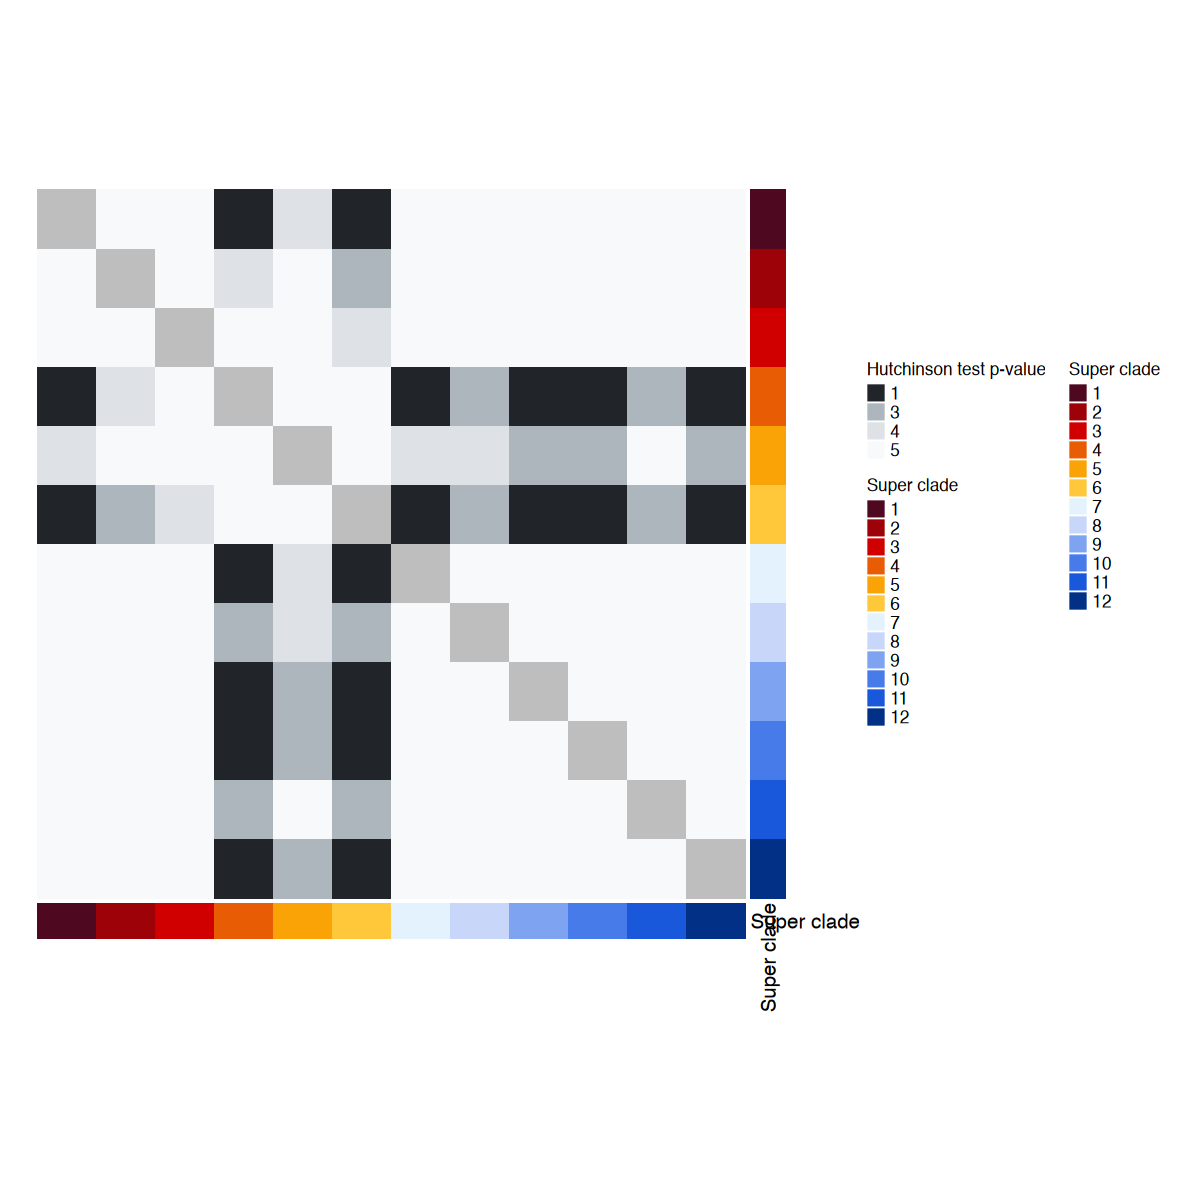

In [79]:
# heatmap of p values
row_annotation <- data.frame(unlist(str_split(colnames(t$p.values)," "))[seq(1,12*4,4)])
rownames(row_annotation) <- rownames(t$p.values)
colnames(row_annotation) <- c("Super clade")
row_annotation$`Super clade` <- factor(row_annotation$`Super clade`, levels = sprintf("%s",1:12))

row_annotation_h <- ComplexHeatmap::rowAnnotation(df = row_annotation,
                                                  col = list(`Super clade` = c("1" = "#4e0921",
                                                                               "2" = "#9d0208",
                                                                               "3" = "#d00000",
                                                                               "4" = "#e85d04",
                                                                               "5" = "#faa307",
                                                                               "6" = "#ffc83b",
                                                                               "7" = "#e3f2fd",
                                                                               "8" = "#c8d7f9",
                                                                               "9" = "#7ea3f1",
                                                                               "10" = "#487bea",
                                                                               "11" = "#1957db",
                                                                               "12" = "#023087")),
                                                  simple_anno_size = unit(0.75, "cm"),
                                                  annotation_name_side = "bottom")


column_annotation_h <- ComplexHeatmap::HeatmapAnnotation(df = row_annotation,
                                                  col = list(`Super clade` = c("1" = "#4e0921",
                                                                               "2" = "#9d0208",
                                                                               "3" = "#d00000",
                                                                               "4" = "#e85d04",
                                                                               "5" = "#faa307",
                                                                               "6" = "#ffc83b",
                                                                               "7" = "#e3f2fd",
                                                                               "8" = "#c8d7f9",
                                                                               "9" = "#7ea3f1",
                                                                               "10" = "#487bea",
                                                                               "11" = "#1957db",
                                                                               "12" = "#023087")),
                                                  simple_anno_size = unit(0.75, "cm"),
                                                  annotation_name_side = "right")


new_t <- t$p.values
new_t[t$p.values < 0.001] <- 1
new_t[t$p.values >= 0.001 & t$p.values < 0.01] <- 2
new_t[t$p.values >= 0.01 & t$p.values < 0.05] <- 3
new_t[t$p.values >= 0.05 & t$p.values < 0.1] <- 4
new_t[t$p.values >= 0.1] <- 5

# Define the heatmap
options(repr.plot.width=10, repr.plot.height=10)

h <- ComplexHeatmap::Heatmap(new_t, col = c("1" = "#212529",
                                            "2" = "#495057",
                                            "3" = "#adb5bd",
                                            "4" = "#dee2e6",
                                            "5" = "#f8f9fa"),
                             show_column_names = FALSE,
                             show_row_names = FALSE,
                             cluster_rows = F,
                             cluster_columns = F,
                             bottom_annotation = column_annotation_h,
                             right_annotation = row_annotation_h,  
                             heatmap_legend_param = list(title = "Hutchinson test p-value",legend_direction = "horizontal"),
                             width = unit(15,"cm"),
                             height = unit(15,"cm"))

ComplexHeatmap::draw(h)

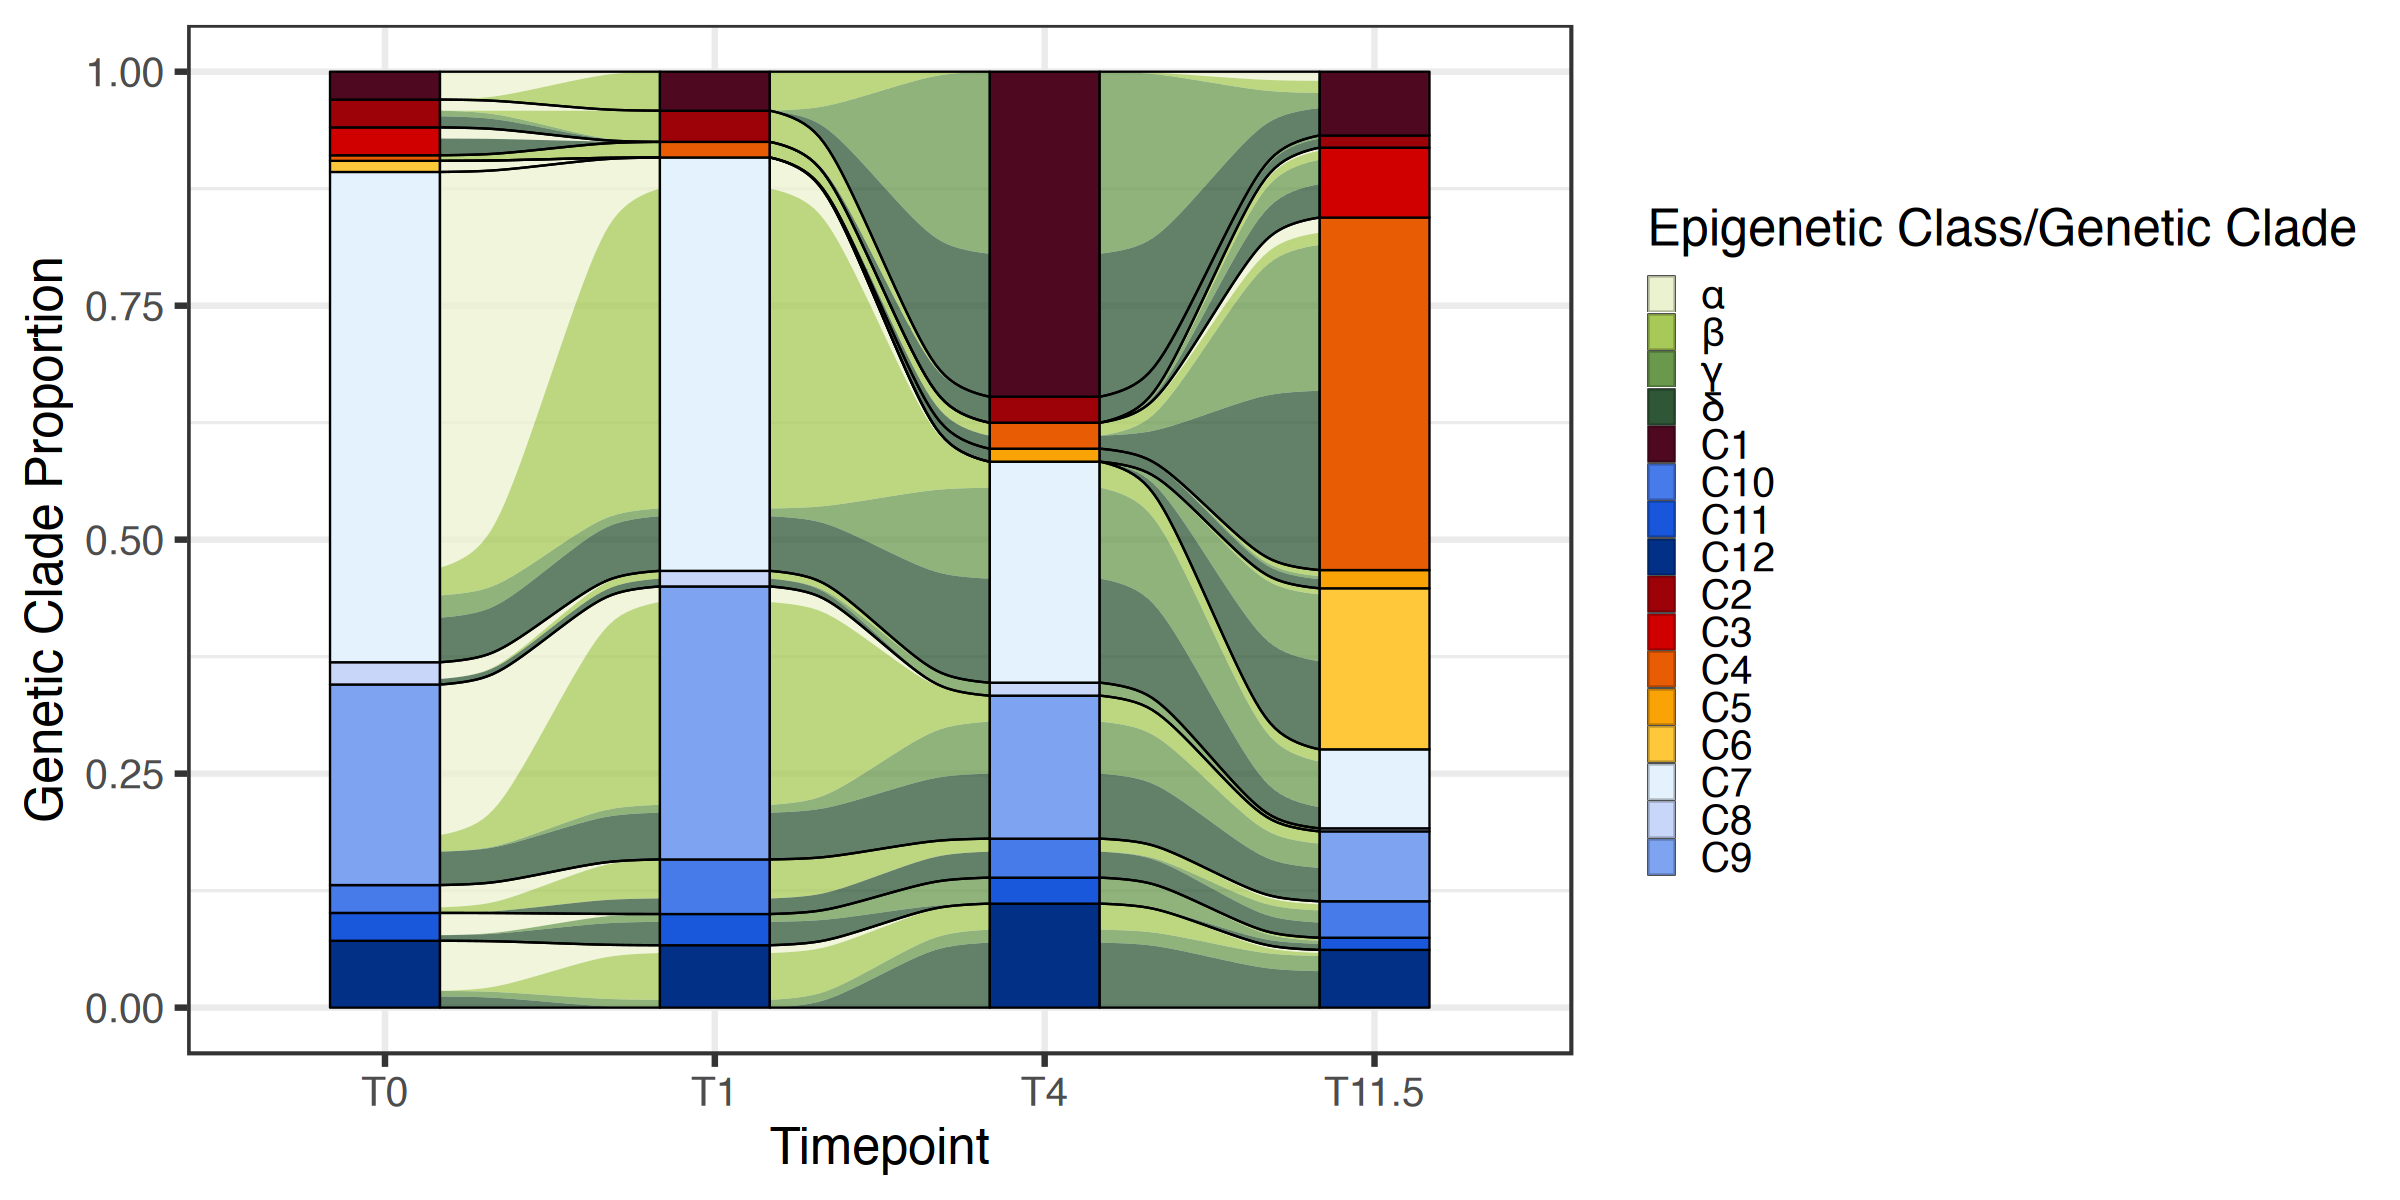

In [87]:
# Plot epigenetic class evolution in each genetic clade

# Genetic clades
clades <- data.frame(read_csv("../Data/CNA_Data/Processed/Genetic_Clades_And_SuperClades.csv",
                              col_types = "ccc"))
rownames(clades) <- clades$Cell_id

# Epigenetic classes
epi_classes_df <- data.frame(read_csv("../Data/ATAC_Data/GeneExpressionScores/DATAC/DATAC_Consensus_EpigeneticClasses_C4.csv",
                                     col_types = "ccd"))
rownames(epi_classes_df) <- epi_classes_df$Cell_id
epi_classes_df <- epi_classes_df[order(epi_classes_df$consensus_cluster),]

# Time point
time <- c()
time[grep("POT",epi_classes_df$Cell_id)] <- "T0"
time[grep("DSIa|DSIb",epi_classes_df$Cell_id)] <- "T1"
time[grep("DSIV",epi_classes_df$Cell_id)] <- "T4"
time[grep("DT1_P1",epi_classes_df$Cell_id)] <- "T11.5"

time <- factor(time,levels = c("T0","T1","T4","T11.5"))

# Plotting data
data_plot <- epi_classes_df %>% dplyr::mutate(Timepoint = time) %>%
  dplyr::mutate(Clade = clades[epi_classes_df$Cell_id,]$SuperClade)

data_plot$Timepoint <- factor(data_plot$Timepoint,levels = c("T0","T1","T4","T11.5"))

counts <- c()
table <- c()
class_num <- unique(data_plot$consensus_cluster)
for (t in c("T0","T1","T4","T11.5")){
  for (s in unique(data_plot$Clade)){
    temp <- data_plot[data_plot$Clade == s & data_plot$Timepoint == t,]
    if (nrow(temp) == 0){
      counts <- cbind(rep(t,length(class_num)),
                      rep(sprintf("C%s",s),length(class_num)),
                      class_num,
                      rep(0,length(class_num)))
      table <- rbind(table,counts)
    } else {
      prop_temp <- table(temp$consensus_cluster)
      if (length(prop_temp) == length(class_num )){
        counts <- cbind(rep(t,length(class_num)),
                        rep(sprintf("C%s",s),length(class_num)),
                        names(prop_temp),
                        prop_temp[1:length(prop_temp)])
        table <- rbind(table,counts)
      } else {
        missing <- class_num[which(! class_num %in% names(prop_temp))]
        counts <- cbind(rep(t,length(class_num)),
                        rep(sprintf("C%s",s),length(class_num )),
                        c(names((prop_temp)), missing),
                        c(prop_temp[1:length(prop_temp)],rep(0,length(missing))))
        table <- rbind(table,counts)
      }
    }
  }
}
table <- data.frame(table)
colnames(table) <- c("Timepoint","Genetic clade","Epigenetic class","Counts") 

table$Counts <- as.numeric(table$Counts)
table$Timepoint <- factor(table$Timepoint,levels = c("T0","T1","T4","T11.5"))

genetic_clade_colours <- c("C1" = "#4e0921",
                           "C2" = "#9d0208",
                           "C3" = "#d00000",
                           "C4" = "#e85d04",
                           "C5" = "#faa307",
                           "C6" = "#ffc83b",
                           "C7" = "#e3f2fd",
                           "C8" = "#c8d7f9",
                           "C9" = "#7ea3f1",
                           "C10" = "#487bea",
                           "C11" = "#1957db",
                           "C12" = "#023087")

epigenetic_class_colours <- c("α" = "#ebf2cf",
                              "β" = "#a7c957",
                              "γ" = "#6a994e",
                              "δ" = "#2f5637")



Genetic_Clade_Prop <- c()
for (time in c("T0","T1","T4","T11.5")) {
  sum <- sum(table[table$Timepoint == time,]$Counts)
  for (clade in unique(table$`Genetic clade`)){
    Genetic_Clade_Prop <- c(Genetic_Clade_Prop,table[table$`Genetic clade` == clade & table$Timepoint == time,]$Counts/sum)
  }
}

table$Genetic_Clade_Prop <- Genetic_Clade_Prop
table$`Genetic clade` <- factor(table$`Genetic clade`, levels = names(genetic_clade_colours))
table$`Epigenetic class` <- factor(table$`Epigenetic class`, levels = names(epigenetic_class_colours))

options(repr.plot.width=20, repr.plot.height=10)

p1 <- ggplot(table, 
             aes(x = Timepoint, stratum = `Genetic clade`, 
                 alluvium = interaction(`Genetic clade`, `Epigenetic class`), 
                 y = Genetic_Clade_Prop)) + 
  geom_stratum(aes(fill = `Genetic clade`), alpha =1) +
  geom_flow(aes(fill = `Epigenetic class`), alpha = 0.75) +
  geom_flow(aes(color = `Genetic clade`), fill = 'NA', color = "black", alpha = 1) +
  scale_fill_manual(name = "Epigenetic Class/Genetic Clade",values = c(genetic_clade_colours,epigenetic_class_colours)) +   
  labs(x = "Timepoint", y = "Genetic Clade Proportion") +
  theme_bw(base_size = 30)
    
suppressWarnings(print(p1))

## Visualising pathway z-score UMAPs labelled by epigenetic class, clade, time point and sample

In [89]:
# Load and format the GSVA pathway z-score matrix 
gsva <- data.frame(read_csv("../Data/ATAC_Data/GeneExpressionScores/DATAC/DATAC_Consensus_HallmarkPathwayScores.csv",
                           col_types = paste("c",rep("d",49), sep = "")))
rownames(gsva) <- gsva[,1]
gsva <- data.frame(gsva[,-1])

colnames(gsva) <- str_replace(colnames(gsva),"HALLMARK_","")
gsva <- t(gsva)

# Load epigenetic classes
epi_classes_df <- data.frame(read_csv("../Data/ATAC_Data/GeneExpressionScores/DATAC/DATAC_Consensus_EpigeneticClasses_C4.csv",
                                     col_types = "cc"))
rownames(epi_classes_df) <- epi_classes_df$Cell_id

# Load genetic clades
clades <- data.frame(read_csv("../Data/CNA_Data/Processed/Genetic_Clades_And_SuperClades.csv",
                              col_types = "ccc"))
# Set rownames for easy sorting
rownames(clades) <- clades$Cell_id

# Generate UMAP data based on hallmark pathway z-scores
data <- t(as.matrix(gsva))
custom.config <- umap.defaults
custom.config$random_state <- 7
umap.1 <- umap(data, config = custom.config)

# Get time point, sample, genetic clade and epigenetic class information for each cell
time <- c()
time[grep("POT",rownames(data))] <- "T0"
time[grep("DSIb|DSIa",rownames(data))] <- "T1"
time[grep("DSIV",rownames(data))] <- "T4"
time[grep("DT1_P1",rownames(data))] <- "T11.5"

time <- factor(time,levels = c("T0","T1","T4","T11.5"))

sample <- c()
sample[grep("POTa|POTm",rownames(data))] <- "T0.A"
sample[grep("POTb|POTp",rownames(data))] <- "T0.B"
sample[grep("DSIa",rownames(data))] <- "T1.A"
sample[grep("DSIb",rownames(data))] <- "T1.B"
sample[grep("DSIVa",rownames(data))] <- "T4.A"
sample[grep("DSIVb",rownames(data))] <- "T4.B"
sample[grep("DT1_P1a",rownames(data))] <- "T11.A"
sample[grep("DT1_P1b",rownames(data))] <-  "T12.B"

sample <- factor(sample,levels = c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))

# UMAP plot dataset
plot_umap.1_df <- data.frame(umap.1$layout) %>% 
  dplyr::mutate(Cell_id = rownames(data)) %>% 
  dplyr::mutate(Genetic_Clade = clades[rownames(data),]$SuperClade) %>%
  dplyr::mutate(Time = time) %>%
  dplyr::mutate(Sample = sample) %>%
  dplyr::mutate(Epigenetic_Class = epi_classes_df[rownames(data),]$consensus_cluster)
colnames(plot_umap.1_df) <- c("x","y","Cell_id","Super_clade","Time","Sample","Epigenetic_Class")

plot_umap.1_df$Super_clade <- factor(plot_umap.1_df$Super_clade, levels = sprintf("%s",1:12))


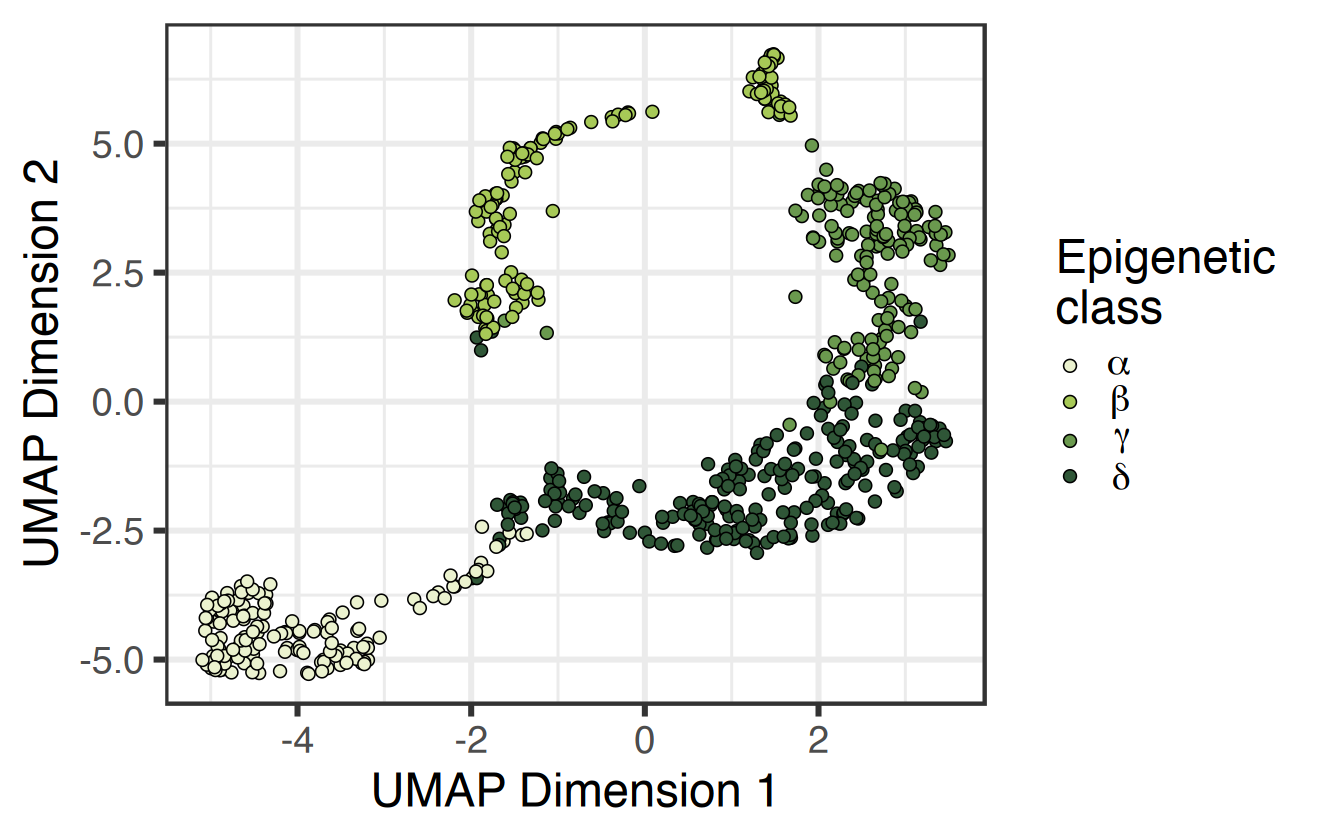

In [100]:
options(repr.plot.width=11, repr.plot.height=7)

p1 <- ggplot(plot_umap.1_df, aes(x = x, y = y, fill = Epigenetic_Class)) +
  geom_point(size = 3, shape = 21, color ="black", alpha = 1) +
  scale_fill_manual(name = "Epigenetic\nclass",
                    values = c("α" = "#ebf2cf",
                               "β" = "#a7c957",
                               "γ" = "#6a994e",
                               "δ" = "#2f5637"),
                    labels = c("α" = expression(alpha), "β" = expression(beta),
                               "γ" = expression(gamma),"δ" =expression(delta))) +
  xlab("UMAP Dimension 1")+
  ylab("UMAP Dimension 2")+
  #guides(fill = "none")+
  theme_bw(base_size = 28) 
p1


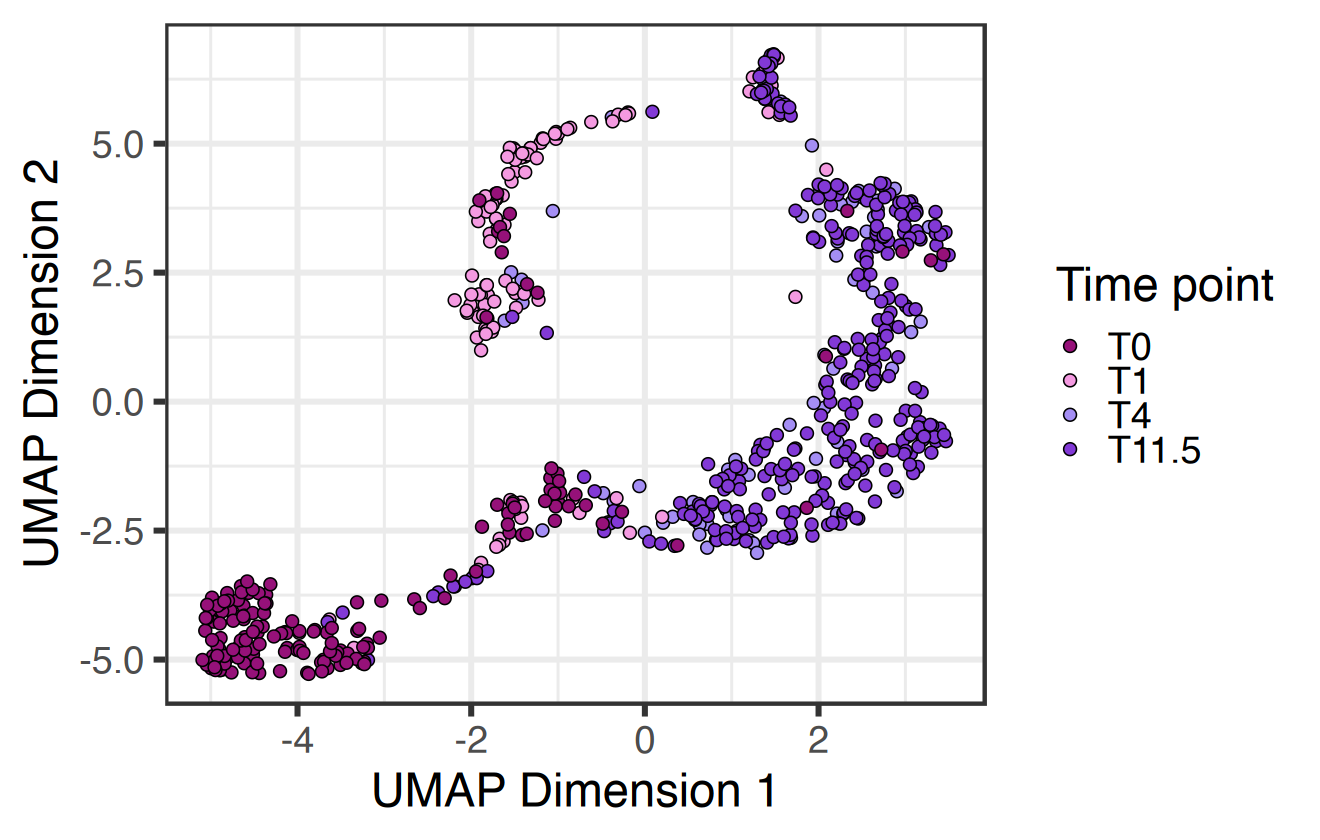

In [96]:
options(repr.plot.width=11, repr.plot.height=7)


p2 <- ggplot(plot_umap.1_df, aes(x = x, y = y, fill = Time)) +
  geom_point(size = 3, shape = 21, color ="black", alpha = 1) +
  scale_fill_manual(name = "Time point",
                    values =  c("T0" = "#961179",
                                "T1" =  "#F49AE1",
                                "T4" = "#A48EF4",
                                "T11.5"= "#8239D6")) +
  xlab("UMAP Dimension 1")+
  ylab("UMAP Dimension 2")+
  #guides(fill = "none")+
  theme_bw(base_size = 28) 
p2


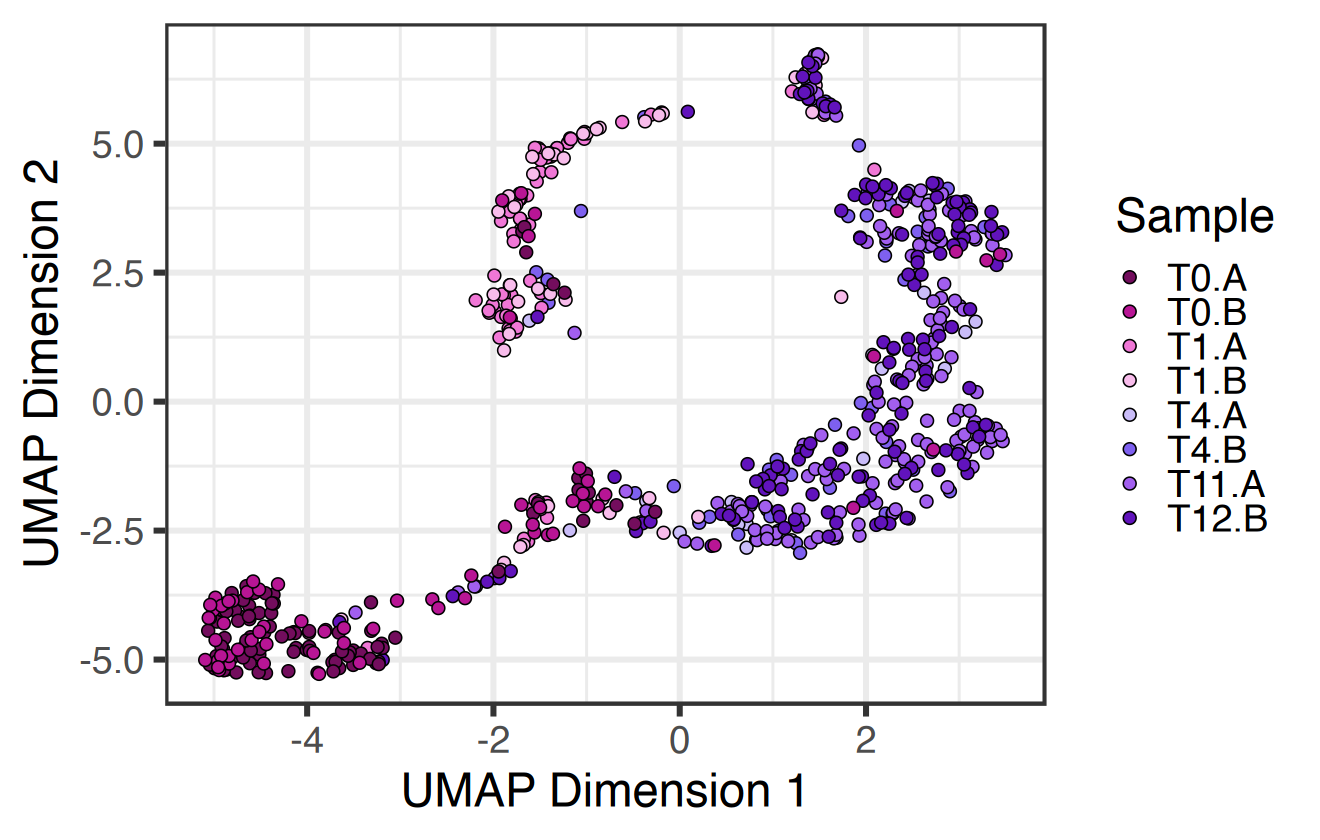

In [94]:
options(repr.plot.width=11, repr.plot.height=7)

p3 <- ggplot(plot_umap.1_df, aes(x = x, y = y, fill = Sample)) +
  geom_point(size = 3, shape = 21, color ="black", alpha = 1) +
  scale_fill_manual(name = "Sample",
                    values = c("T0.A" = "#730d5d",
                               "T0.B" = "#b81595",
                               "T1.A" =  "#f077d6",
                               "T1.B" =  "#f8bceb",
                               "T4.A" = "#c9bcf8",
                               "T4.B" = "#7e60ef",
                               "T11.A"= "#a25fef",
                               "T12.B"= "#6113bc")) +
  xlab("UMAP Dimension 1")+
  ylab("UMAP Dimension 2")+
  #guides(fill = "none")+
  theme_bw(base_size = 28) 
p3


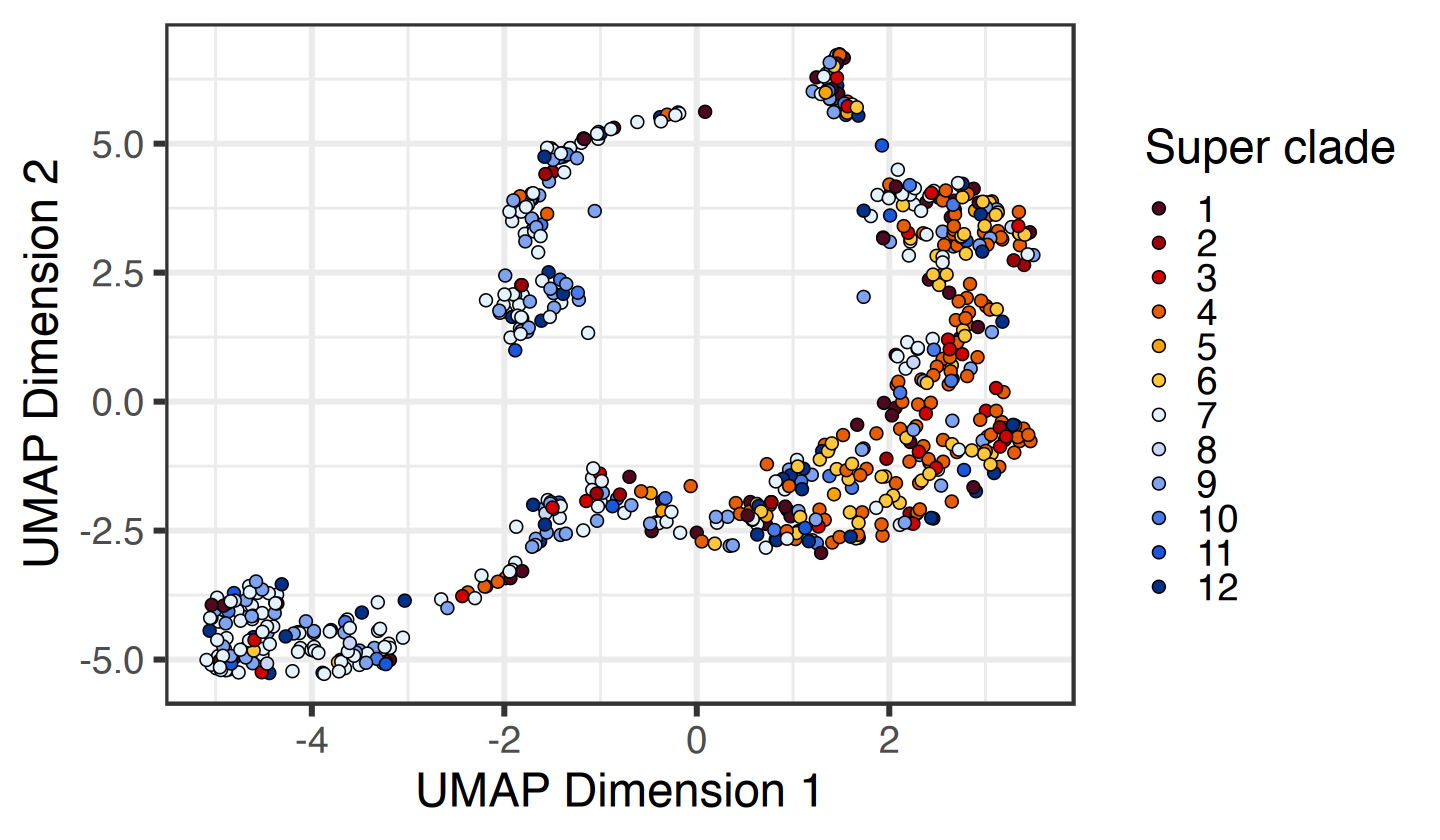

In [104]:
options(repr.plot.width=12, repr.plot.height=7)

p4 <- ggplot(plot_umap.1_df, aes(x = x, y = y, fill =Super_clade)) +
  geom_point(size = 3, shape = 21, color ="black", alpha = 1) +
  scale_fill_manual(name = "Super clade",
                    values = c("1" = "#4e0921",
                               "2" = "#9d0208",
                               "3" = "#d00000",
                               "4" = "#e85d04",
                               "5" = "#faa307",
                               "6" = "#ffc83b",
                               "7" = "#e3f2fd",
                               "8" = "#c8d7f9",
                               "9" = "#7ea3f1",
                               "10" = "#487bea",
                               "11" = "#1957db",
                               "12" = "#023087")) +
  xlab("UMAP Dimension 1")+
  ylab("UMAP Dimension 2")+
  #guides(fill = "none")+
  theme_bw(base_size = 28) 
p4

## Visualising th TF family binding site activity heatmap

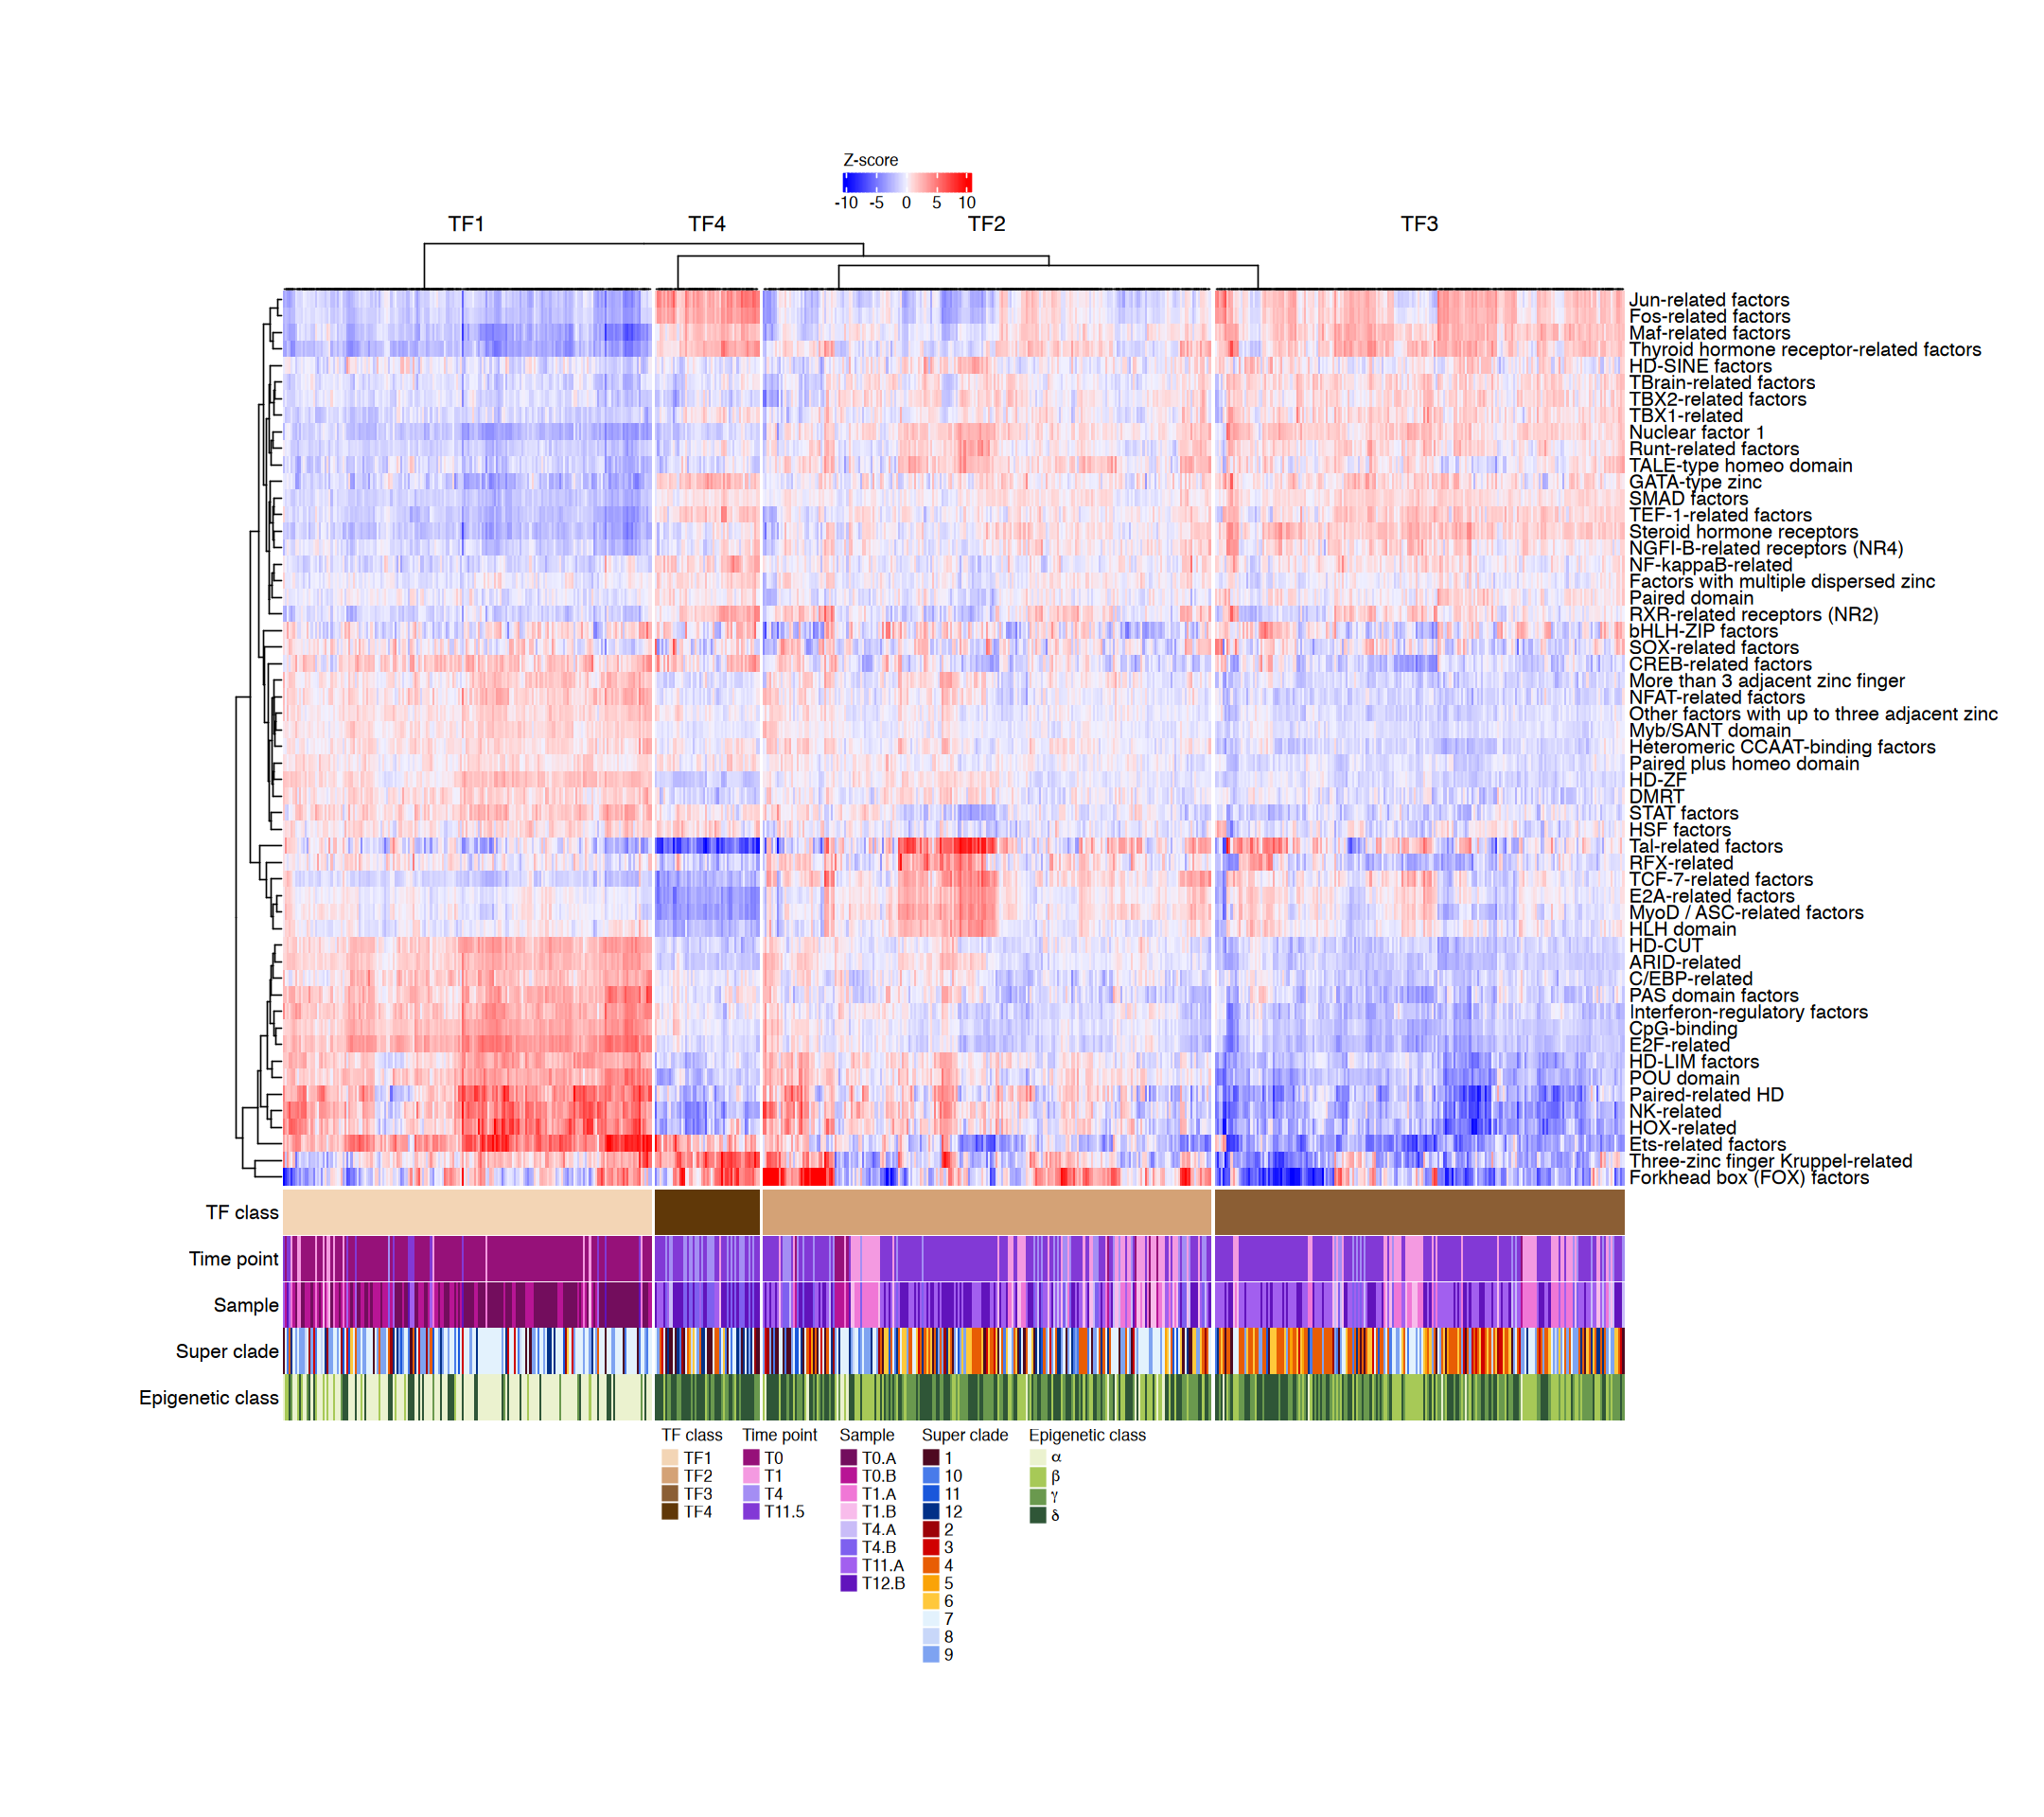

In [22]:
# Load and format the GSVA pathway z-score matrix 
tfbs <- data.frame(read_csv("../Data/ATAC_Data/TFBSScores/DATAC_Consensus_TFBS_Scores.csv",
                           col_types = paste("c",rep("d",513), sep = "")))
rownames(tfbs) <-tfbs[,1]
tfbs<- data.frame(tfbs[,-1])

# Load tf classes
tf_classes_df <- data.frame(read_csv("../Data/ATAC_Data/TFBSScores/DATAC_Consensus_TFClasses_C4.csv",
                                     col_types = "ccc"))
rownames(tf_classes_df) <- tf_classes_df$cell_id
tf_classes_df <- tf_classes_df[order(tf_classes_df$consensus_cluster),]

# Load epigenetic classes
epi_classes_df <- data.frame(read_csv("../Data/ATAC_Data/GeneExpressionScores/DATAC/DATAC_Consensus_EpigeneticClasses_C4.csv",
                                     col_types = "ccc"))
rownames(epi_classes_df) <- epi_classes_df$Cell_id
epi_classes_df <- epi_classes_df[tf_classes_df$cell_id,]

# Reorder the data
tfbs <- tfbs[,tf_classes_df$cell_id]

# Define the time point for each cell in 'tf_classes$cell_id'
time <- c()
time[grep("POT",tf_classes_df$cell_id)] <- "T0"
time[grep("DSIb|DSIa",tf_classes_df$cell_id)] <- "T1"
time[grep("DSIV",tf_classes_df$cell_id)] <- "T4"
time[grep("DT1_P1",tf_classes_df$cell_id)] <- "T11.5"

time <- factor(time,levels = c("T0","T1","T4","T11.5"))

# Define the sample for each cell in 'tf_classes_df$cell_id'
sample <- c()
sample[grep("POTm|POTa",tf_classes_df$cell_id)] <- "T0.A"
sample[grep("POTp|POTb",tf_classes_df$cell_id)] <- "T0.B"
sample[grep("DSIa",tf_classes_df$cell_id)] <- "T1.A"
sample[grep("DSIb",tf_classes_df$cell_id)] <- "T1.B"
sample[grep("DSIVa",tf_classes_df$cell_id)] <- "T4.A"
sample[grep("DSIVb",tf_classes_df$cell_id)] <- "T4.B"
sample[grep("DT1_P1a",tf_classes_df$cell_id)] <- "T11.A"
sample[grep("DT1_P1b",tf_classes_df$cell_id)] <- "T12.B"

sample <- factor(sample,levels = c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))

# Define the clade for each cell in 'tf_classes_df$cell_id'
# genetic clades
clades <- data.frame(read_csv("../Data/CNA_Data/Processed/Genetic_Clades_And_SuperClades.csv",
                              col_types = "ccc"))
rownames(clades) <- clades$Cell_id
clade <- clades[tf_classes_df$cell_id,]$SuperClade

# Define column annotations
column_annotation <- data.frame(tf_classes_df$consensus_cluster,time,sample,clade,epi_classes_df$consensus_cluster)
colnames(column_annotation) <- c("TF class","Time point","Sample","Super clade", "Epigenetic class")
rownames(column_annotation) <- tf_classes_df$cell_id



column_annotation_h <- ComplexHeatmap::HeatmapAnnotation(df = column_annotation,
                                                         col = list( `TF class` = c("TF1" = "#f3d5b5",
                                                                                    "TF2" = "#d4a276",
                                                                                    "TF3" = "#8b5e34",
                                                                                    "TF4" = "#603808"),
                                                                    `Epigenetic class` = c("\u03B1" = "#ebf2cf",
                                                                                           "\u03B2" = "#a7c957",
                                                                                           "\u03B3" = "#6a994e",
                                                                                           "\u03B4" = "#2f5637"),
                                                                    `Sample` = c("T0.A" = "#730d5d",
                                                                                 "T0.B" = "#b81595",
                                                                                 "T1.A" =  "#f077d6",
                                                                                 "T1.B" =  "#f8bceb",
                                                                                 "T4.A" = "#c9bcf8",
                                                                                 "T4.B" = "#7e60ef",
                                                                                 "T11.A"= "#a25fef",
                                                                                 "T12.B"= "#6113bc"),
                                                                    `Time point` =  c("T0" = "#961179",
                                                                                      "T1" =  "#F49AE1",
                                                                                      "T4" = "#A48EF4",
                                                                                      "T11.5"= "#8239D6"),
                                                                    `Super clade` = c("1" = "#4e0921",
                                                                                     "2" = "#9d0208",
                                                                                     "3" = "#d00000",
                                                                                     "4" = "#e85d04",
                                                                                     "5" = "#faa307",
                                                                                     "6" = "#ffc83b",
                                                                                     "7" = "#e3f2fd",
                                                                                     "8" = "#c8d7f9",
                                                                                     "9" = "#7ea3f1",
                                                                                     "10" = "#487bea",
                                                                                     "11" = "#1957db",
                                                                                     "12" = "#023087")),
                                                         annotation_legend_param = list(
                                                           `TF class`= list(legend_direction = "horizontal"),
                                                           `Epigenetic class` = list(legend_direction = "horizontal",
                                                                                     at = c("\u03B1", "\u03B2", "\u03B3", "\u03B4"),
                                                                                     labels = c(expression(alpha), expression(beta), expression(gamma), expression(delta))),
                                                           `Time point`= list(legend_direction = "horizontal"),
                                                           `Sample`= list(legend_direction = "horizontal"),
                                                           `Super clade`= list(legend_direction = "horizontal")
                                                         ),
                                                         simple_anno_size = unit(1, "cm"),
                                                         annotation_name_side = "left")




# Define the heatmap colours
paletteLength <-20
myColor <- colorRampPalette(c("blue", "white", "red"))(paletteLength)
myBreaks <- c(seq(-10, 0, length.out=ceiling(paletteLength/2)), 
              seq(0, 10, length.out=floor(paletteLength/2)))

colours <- circlize::colorRamp2(myBreaks,myColor) 

dend <- ComplexHeatmap::cluster_within_group(tfbs,tf_classes_df$consensus_cluster)

# Define the heatmap
h <- ComplexHeatmap::Heatmap(as.matrix((tfbs)), col = colours,
                             show_column_names = F,
                             show_row_names = T,
                             cluster_columns = dend,
                             column_split = 4,
                             bottom_annotation = column_annotation_h,
                             heatmap_legend_param = list(title = "Z-score",legend_direction = "horizontal"),
                             width = unit(30,"cm"),
                             height = unit(20,"cm"))

options(repr.plot.width=18, repr.plot.height=16)

# Draw the heatmap
suppressWarnings({
  draw(h, heatmap_legend_side = "top", annotation_legend_side = "bottom")
})


## Visualising TF classes across genetic clades, time and sample

Rows: 668 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): cell_id, consensus_cluster
dbl (1): stability

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


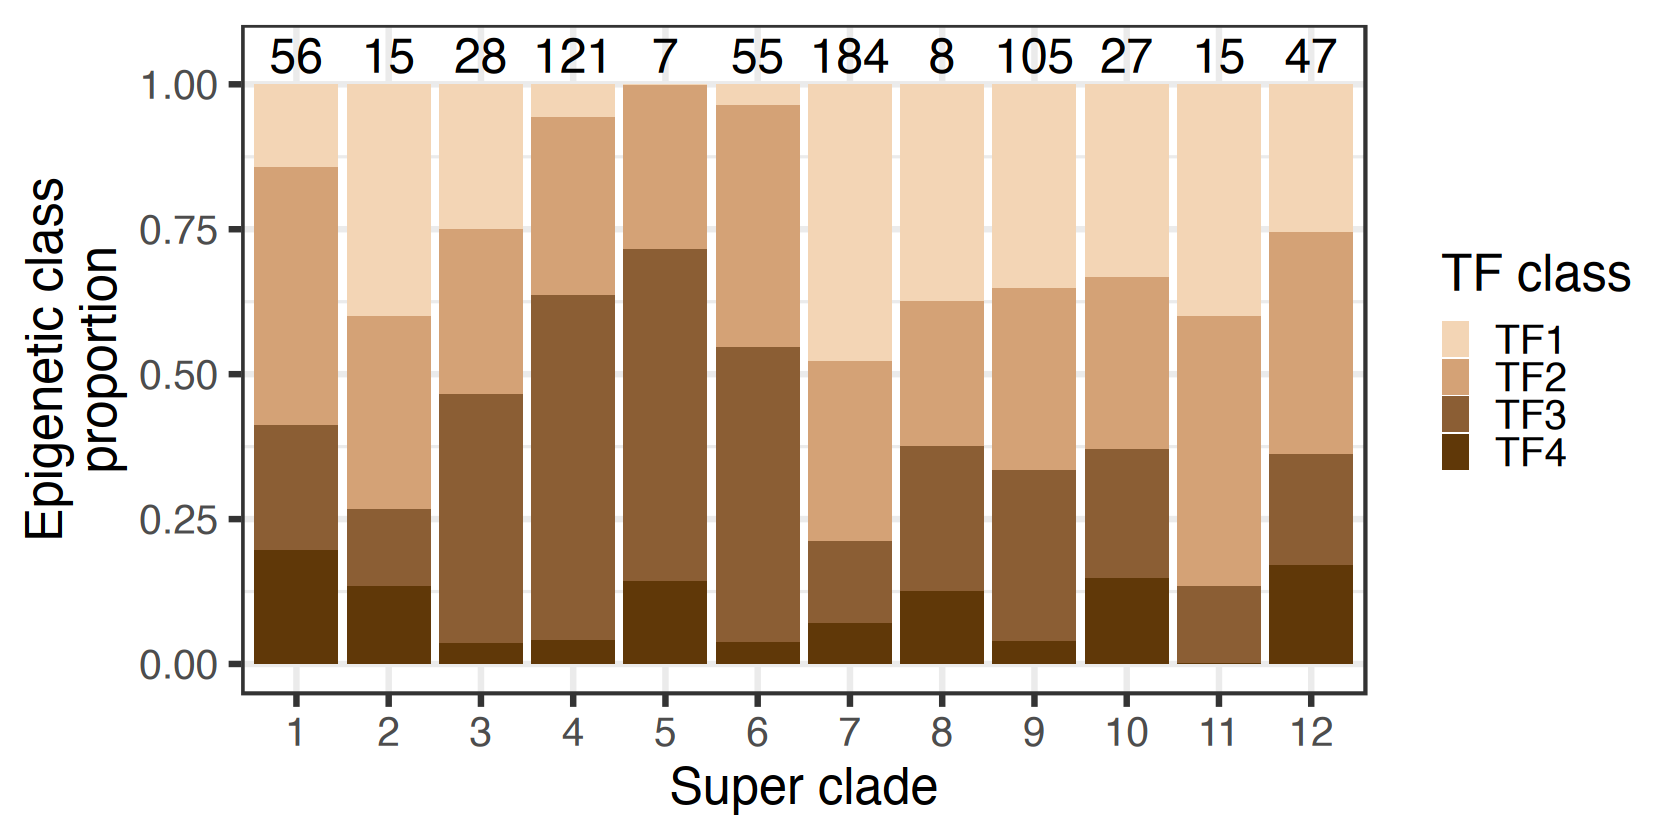

In [11]:
# Load epigenetic classes
epi_classes <- data.frame(read_csv("../Data/ATAC_Data/GeneExpressionScores/DATAC/DATAC_Consensus_EpigeneticClasses_C4.csv",
                                     col_types = "ccc"))
rownames(epi_classes) <- epi_classes$Cell_id

# genetic clades
clades <- data.frame(read_csv("../Data/CNA_Data/Processed/Genetic_Clades_And_SuperClades.csv",
                              col_types = "ccc"))
# Set rownames for easy sorting
rownames(clades) <- clades$Cell_id

# tf classes
tf_classes <- data.frame(read_csv("../Data/ATAC_Data/TFBSScores/DATAC_Consensus_TFClasses_C4.csv",
                                     col_types = "ccc"))
cell_ids <- tf_classes$cell_id

time <- c()
time[grep("POT",tf_classes$cell_id)] <- "T0"
time[grep("DSIb|DSIa",tf_classes$cell_id)] <- "T1"
time[grep("DSIV",tf_classes$cell_id)] <- "T4"
time[grep("DT1_P1",tf_classes$cell_id)] <- "T11/T12"

time <- factor(time,levels = c("T0","T1","T4","T11/T12"))

sample <- c()
sample[grep("POTm|POTa",tf_classes$cell_id)] <- "T0.A"
sample[grep("POTp|POTb",tf_classes$cell_id)] <- "T0.B"
sample[grep("DSIa",tf_classes$cell_id)] <- "T1.A"
sample[grep("DSIb",tf_classes$cell_id)] <- "T1.B"
sample[grep("DSIVa",tf_classes$cell_id)] <- "T4.A"
sample[grep("DSIVb",tf_classes$cell_id)] <- "T4.B"
sample[grep("DT1_P1a",tf_classes$cell_id)] <- "T11.A"
sample[grep("DT1_P1b",tf_classes$cell_id)] <- "T12.B"

sample <- factor(sample,levels = c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))

data_plot <- data.frame("cell_id" = tf_classes$cell_id,
                        "time" = time,
                        "sample" = sample,
                        "epi_class" = epi_classes[tf_classes$cell_id,]$consensus_cluster,
                        "tf_class" = tf_classes$consensus_cluster,
                        "clade" = clades[tf_classes$cell_id,]$SuperClade)

table <- proportions(data = data_plot,obj = "tf_class",cat = "clade", subset = FALSE, sub_group = NA, sub_level = NA)

counts <- data.frame(table(data_plot$clade))
colnames(counts)[1] <- "clade"

table$clade <- factor(table$clade, 1:12)
counts$clade <- factor(counts$clade, 1:12)

p <- ggplot(table, aes(fill = tf_class, x =clade, y = Proportion))+
  geom_bar(position = "fill", stat="identity") +
  scale_fill_manual(name = "TF class",
                    values = c("TF1" = "#f3d5b5",
                               "TF2" = "#d4a276",
                               "TF3" = "#8b5e34",
                               "TF4" = "#603808")) +
  geom_text(data = counts,
            aes(x =`clade`, y = 1.05, label = Freq),
            inherit.aes = F,# slightly above the bar
            size = 10,
            fontface = "bold"
  ) +
  xlab("Super clade")+
  ylab(str_wrap("Epigenetic class proportion", width = 20))+
  theme_bw(base_size = 30)

options(repr.plot.width=14, repr.plot.height=7)
p

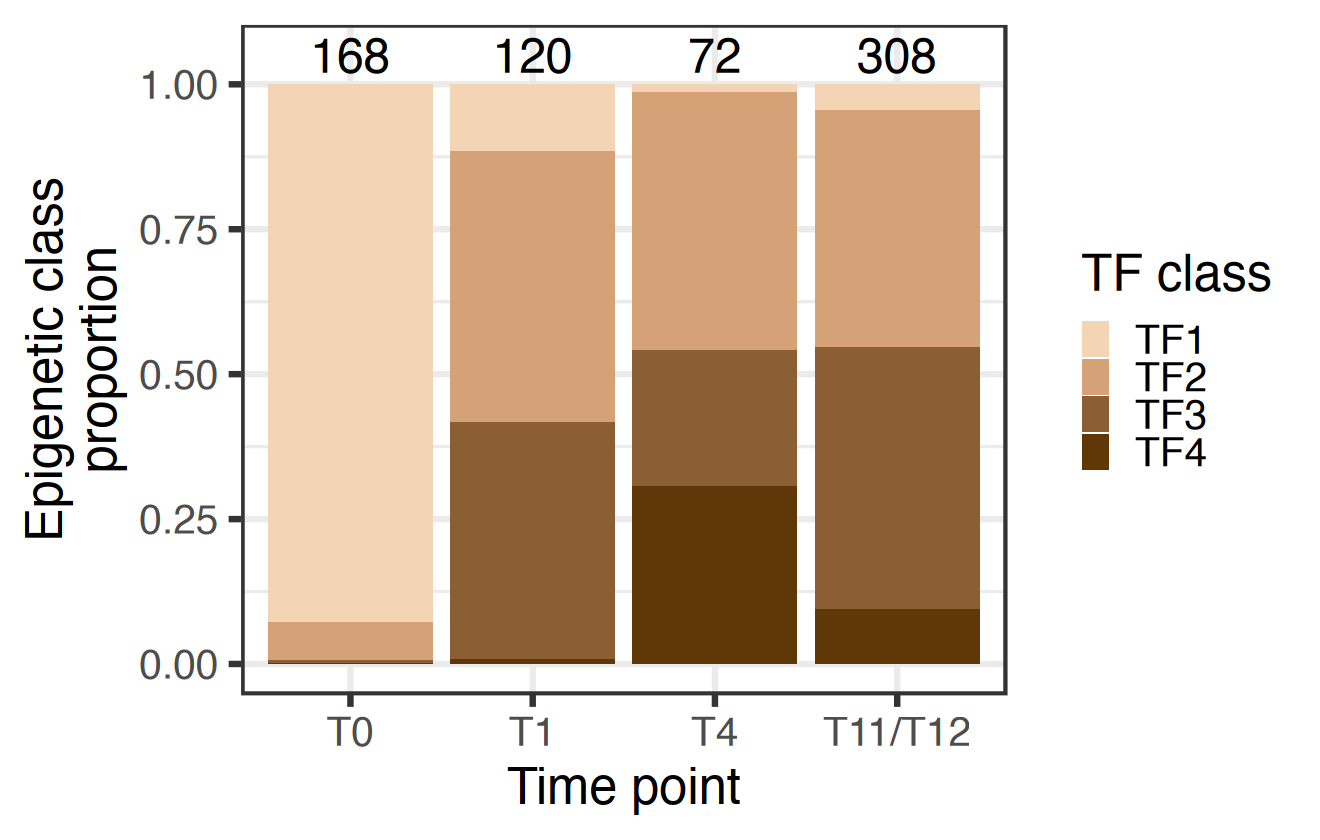

In [14]:
table <- proportions(data = data_plot,obj = "tf_class",cat = "time", subset = FALSE, sub_group = NA, sub_level = NA)
table$time <- factor(table$time,levels =   c("T0","T1","T4","T11/T12"))

counts <- data.frame(table(data_plot$time))
colnames(counts)[1] <- "time"

p <- ggplot(table, aes(fill = tf_class, x =time, y = Proportion))+
  geom_bar(position = "fill", stat="identity") +
  scale_fill_manual(name = "TF class",
                    values = c("TF1" = "#f3d5b5",
                               "TF2" = "#d4a276",
                               "TF3" = "#8b5e34",
                               "TF4" = "#603808")) +
  geom_text(data = counts,
            aes(x =`time`, y = 1.05, label = Freq),
            inherit.aes = F,# slightly above the bar
            size = 10,
            fontface = "bold"
  ) +
  xlab("Time point")+
  ylab(str_wrap("Epigenetic class proportion", width = 20))+
  theme_bw(base_size = 30)
options(repr.plot.width=11, repr.plot.height=7)
p

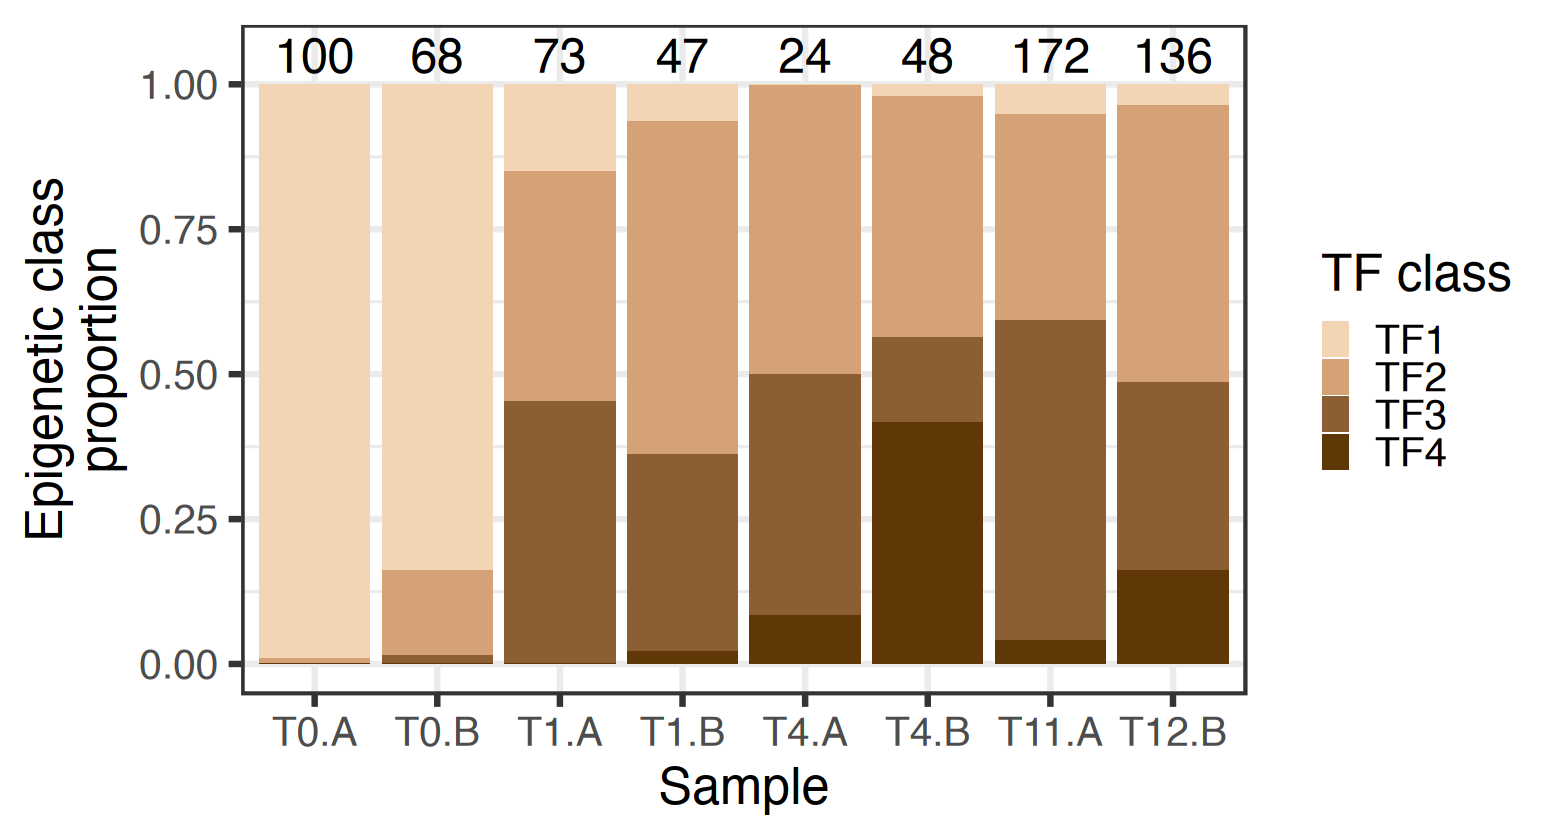

In [16]:
table <- proportions(data = data_plot,obj = "tf_class",cat = "sample", subset = FALSE, sub_group = NA, sub_level = NA)
table$sample <- factor(table$sample,levels =   c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))

counts <- data.frame(table(data_plot$sample))
colnames(counts)[1] <- "sample"


p <- ggplot(table, aes(fill = tf_class, x =sample, y = Proportion))+
  geom_bar(position = "fill", stat="identity") +
  scale_fill_manual(name = "TF class",
                    values = c("TF1" = "#f3d5b5",
                               "TF2" = "#d4a276",
                               "TF3" = "#8b5e34",
                               "TF4" = "#603808")) +
  geom_text(data = counts,
            aes(x =`sample`, y = 1.05, label = Freq),
            inherit.aes = F,# slightly above the bar
            size = 10,
            fontface = "bold"
  ) +
  xlab("Sample")+
  ylab(str_wrap("Epigenetic class proportion", width = 20))+
  theme_bw(base_size = 30)

options(repr.plot.width=13, repr.plot.height=7)
p

## Relationship between epigenetic classes and TF classes

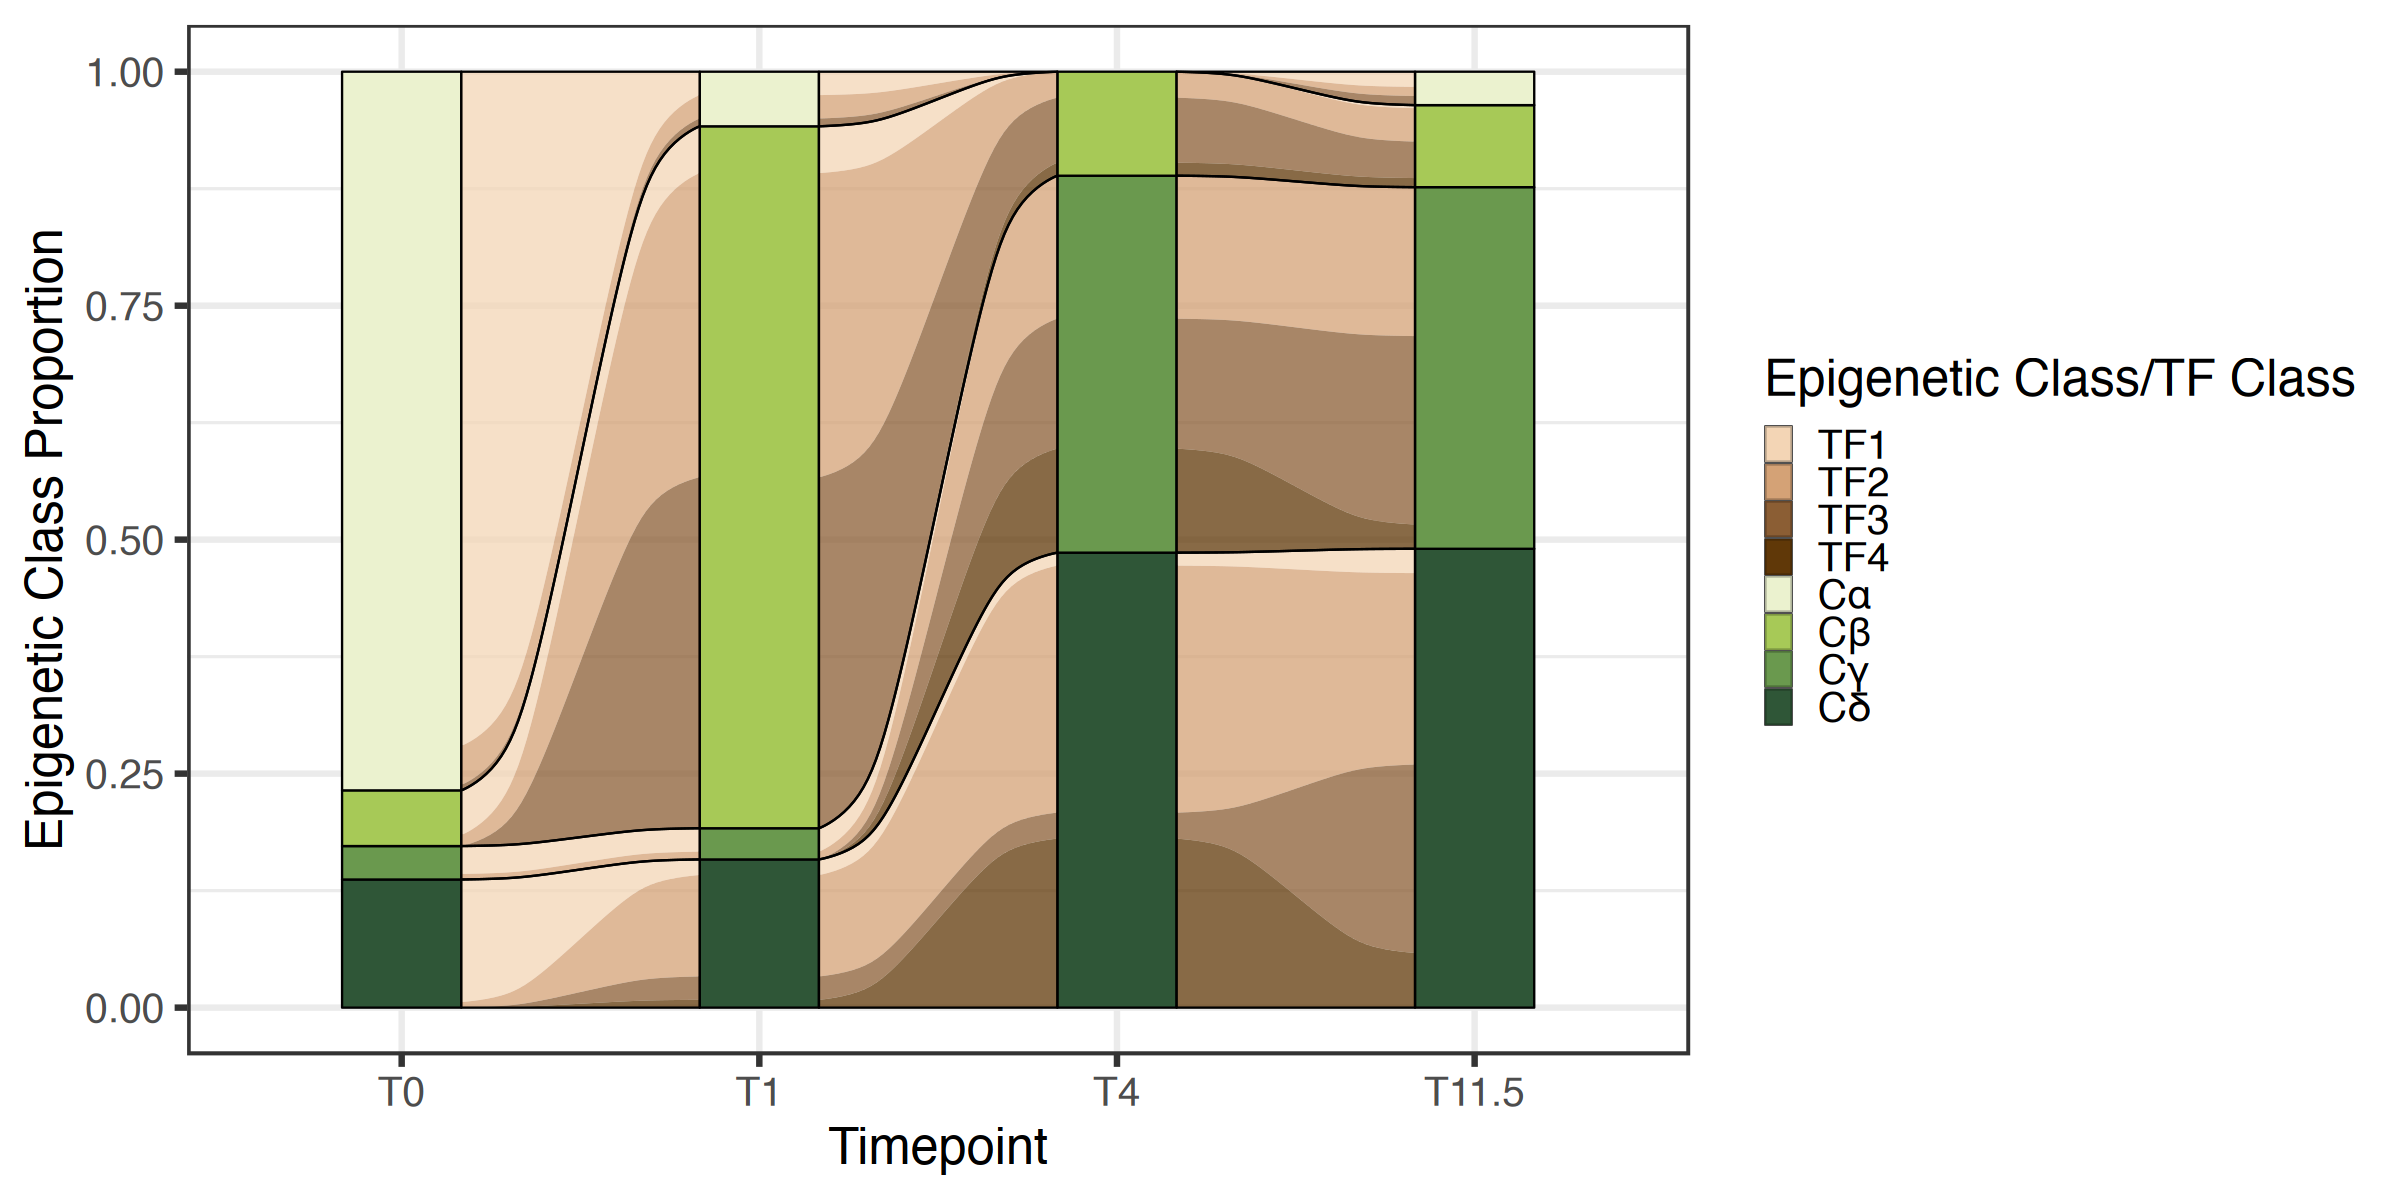

In [20]:
# epigenetic classes
epi_classes <- data.frame(read_csv("../Data/ATAC_Data/GeneExpressionScores/DATAC/DATAC_Consensus_EpigeneticClasses_C4.csv",
                                     col_types = "ccc"))
rownames(epi_classes) <- epi_classes$Cell_id

# Epigenetic classes
tf_classes_df <- data.frame(read_csv("../Data/ATAC_Data/TFBSScores/DATAC_Consensus_TFClasses_C4.csv",
                                     col_types = "ccc"))
rownames(tf_classes_df) <- tf_classes_df$cell_id
tf_classes_df <- tf_classes_df[order(tf_classes_df$consensus_cluster),]

# Time point
time <- c()
time[grep("POT",tf_classes_df$cell_id)] <- "T0"
time[grep("DSIa|DSIb",tf_classes_df$cell_id)] <- "T1"
time[grep("DSIV",tf_classes_df$cell_id)] <- "T4"
time[grep("DT1_P1",tf_classes_df$cell_id)] <- "T11.5"

time <- factor(time,levels = c("T0","T1","T4","T11.5"))

# Plotting data
data_plot <- tf_classes_df %>% dplyr::mutate(Timepoint = time) %>%
  dplyr::mutate(Class = epi_classes[tf_classes_df$cell_id,]$consensus_cluster)

data_plot$Timepoint <- factor(data_plot$Timepoint,levels = c("T0","T1","T4","T11.5"))

counts <- c()
table <- c()
class_num <- unique(data_plot$consensus_cluster)
for (t in c("T0","T1","T4","T11.5")){
  for (s in unique(data_plot$Class)){
    temp <- data_plot[data_plot$Class == s & data_plot$Timepoint == t,]
    if (nrow(temp) == 0){
      counts <- cbind(rep(t,length(class_num)),
                      rep(sprintf("C%s",s),length(class_num)),
                      class_num,
                      rep(0,length(class_num)))
      table <- rbind(table,counts)
    } else {
      prop_temp <- table(temp$consensus_cluster)
      if (length(prop_temp) == length(class_num )){
        counts <- cbind(rep(t,length(class_num)),
                        rep(sprintf("C%s",s),length(class_num)),
                        names(prop_temp),
                        prop_temp[1:length(prop_temp)])
        table <- rbind(table,counts)
      } else {
        missing <- class_num[which(! class_num %in% names(prop_temp))]
        counts <- cbind(rep(t,length(class_num)),
                        rep(sprintf("C%s",s),length(class_num )),
                        c(names((prop_temp)), missing),
                        c(prop_temp[1:length(prop_temp)],rep(0,length(missing))))
        table <- rbind(table,counts)
      }
    }
  }
}
table <- data.frame(table)
colnames(table) <- c("Timepoint","Epigenetic class","TF class","Counts") 

table$Counts <- as.numeric(table$Counts)
table$Timepoint <- factor(table$Timepoint,levels = c("T0","T1","T4","T11.5"))

epi_class_colours <- c("Cα" = "#ebf2cf",
                       "Cβ" = "#a7c957",
                       "Cγ" = "#6a994e",
                       "Cδ" = "#2f5637")

tf_class_colours <- c("TF1" = "#f3d5b5",
                      "TF2" = "#d4a276",
                      "TF3" = "#8b5e34",
                      "TF4" = "#603808")



Epi_Class_Prop <- c()
for (time in c("T0","T1","T4","T11.5")) {
  sum <- sum(table[table$Timepoint == time,]$Counts)
  for (class in unique(table$`Epigenetic class`)){
    Epi_Class_Prop <- c(Epi_Class_Prop,table[table$`Epigenetic class` == class & table$Timepoint == time,]$Counts/sum)
  }
}

table$Epi_Class_Prop <- Epi_Class_Prop
table$`Epigenetic class` <- factor(table$`Epigenetic class`, levels = names(epi_class_colours))
table$`TF class` <- factor(table$`TF class`, levels = names(tf_class_colours))

options(repr.plot.width=20, repr.plot.height=10)
p1 <- ggplot(table, 
             aes(x = Timepoint, stratum = `Epigenetic class`, 
                 alluvium = interaction(`Epigenetic class`, `TF class`), 
                 y = Epi_Class_Prop)) + 
  geom_stratum(aes(fill = `Epigenetic class`), alpha =1) +
  geom_flow(aes(fill = `TF class`), alpha = 0.75) +
  geom_flow(aes(color = `Epigenetic class`), fill = 'NA', color = "black", alpha = 1) +
  scale_fill_manual(name = "Epigenetic Class/TF Class",values = c(epi_class_colours,tf_class_colours)) +   
  labs(x = "Timepoint", y = "Epigenetic Class Proportion") +
  theme_bw(base_size = 30)

options(repr.plot.width=20, repr.plot.height=10)
suppressWarnings(print(p1))

## Visualising TF family z-score UMAPs labelled by TF class, epigenetic class, clade, time point and sample

In [24]:
data <- t(as.matrix(tfbs))

custom.config <- umap.defaults
custom.config$random_state <- 7

umap.1 <- umap(data, config = custom.config)

time <- c()
time[grep("POT",rownames(data))] <- "T0"
time[grep("DSIb|DSIa",rownames(data))] <- "T1"
time[grep("DSIV",rownames(data))] <- "T4"
time[grep("DT1_P1",rownames(data))] <- "T11.5"

time <- factor(time,levels = c("T0","T1","T4","T11.5"))

# Define the sample for each cell in 'rownames(data)'
sample <- c()
sample[grep("POTm|POTa",rownames(data))] <- "T0.A"
sample[grep("POTp|POTb",rownames(data))] <- "T0.B"
sample[grep("DSIa",rownames(data))] <- "T1.A"
sample[grep("DSIb",rownames(data))] <- "T1.B"
sample[grep("DSIVa",rownames(data))] <- "T4.A"
sample[grep("DSIVb",rownames(data))] <- "T4.B"
sample[grep("DT1_P1a",rownames(data))] <- "T11.A"
sample[grep("DT1_P1b",rownames(data))] <- "T12.B"

sample <- factor(sample,levels = c("T0.A","T0.B","T1.A","T1.B","T4.A","T4.B","T11.A","T12.B"))

# Load epigenetic classes
epi_classes_df <- data.frame(read_csv("../Data/ATAC_Data/GeneExpressionScores/DATAC/DATAC_Consensus_EpigeneticClasses_C4.csv",
                                     col_types = "ccc"))
rownames(epi_classes_df) <- epi_classes_df$Cell_id


# Load tf classes
tf_classes_df <- data.frame(read_csv("../Data/ATAC_Data/TFBSScores/DATAC_Consensus_TFClasses_C4.csv",
                                     col_types = "ccc"))
rownames(tf_classes_df) <- tf_classes_df$cell_id

plot_umap.1_df <- data.frame(umap.1$layout) %>% 
  dplyr::mutate(cell_id = rownames(data)) %>% 
  dplyr::mutate(clade = clades[rownames(data),]$SuperClade) %>%
  dplyr::mutate(timepoint = time) %>%
  dplyr::mutate(sample = sample) %>%
  dplyr::mutate(epi_class = epi_classes_df[rownames(data),]$consensus_cluster) %>%
  dplyr::mutate(tf_class = tf_classes_df[rownames(data),]$consensus_cluster)

colnames(plot_umap.1_df) <- c("x","y","cell_id","Clade","Time","Sample","Epiclass","TFClass")
plot_umap.1_df$Clade <- factor(plot_umap.1_df$Clade, sprintf("%s",1:12))

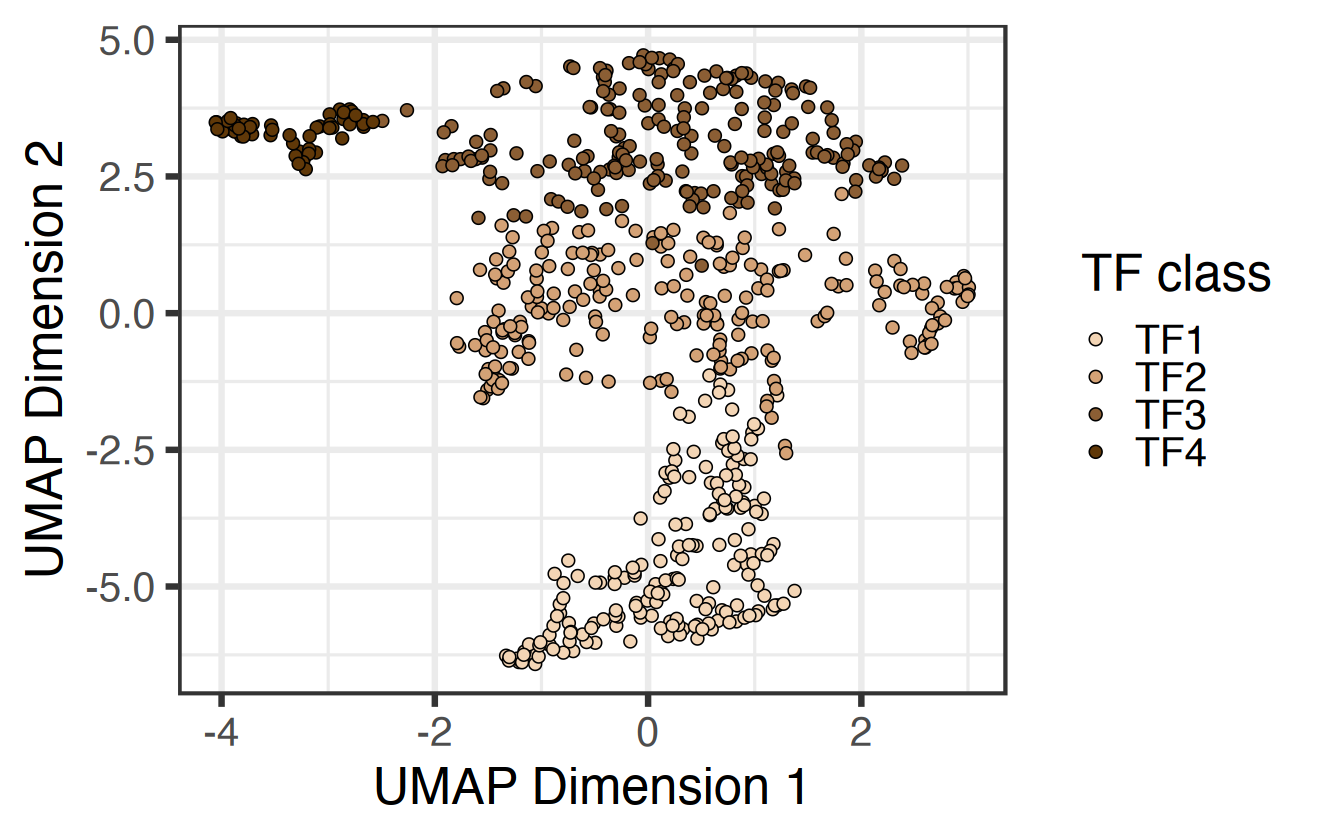

In [27]:
options(repr.plot.width=11, repr.plot.height=7)

p1 <- ggplot(plot_umap.1_df, aes(x = x, y = y, fill = factor(TFClass))) +
  geom_point(size = 3, shape = 21, color ="black", alpha = 1) +
  scale_fill_manual(name = "TF class",
                    values =  c("TF1" = "#f3d5b5",
                                "TF2" = "#d4a276",
                                "TF3" = "#8b5e34",
                                "TF4" = "#603808")) +
  #guides(fill = "none")+
  xlab("UMAP Dimension 1")+
  ylab("UMAP Dimension 2")+
  theme_bw(base_size = 30) 
p1

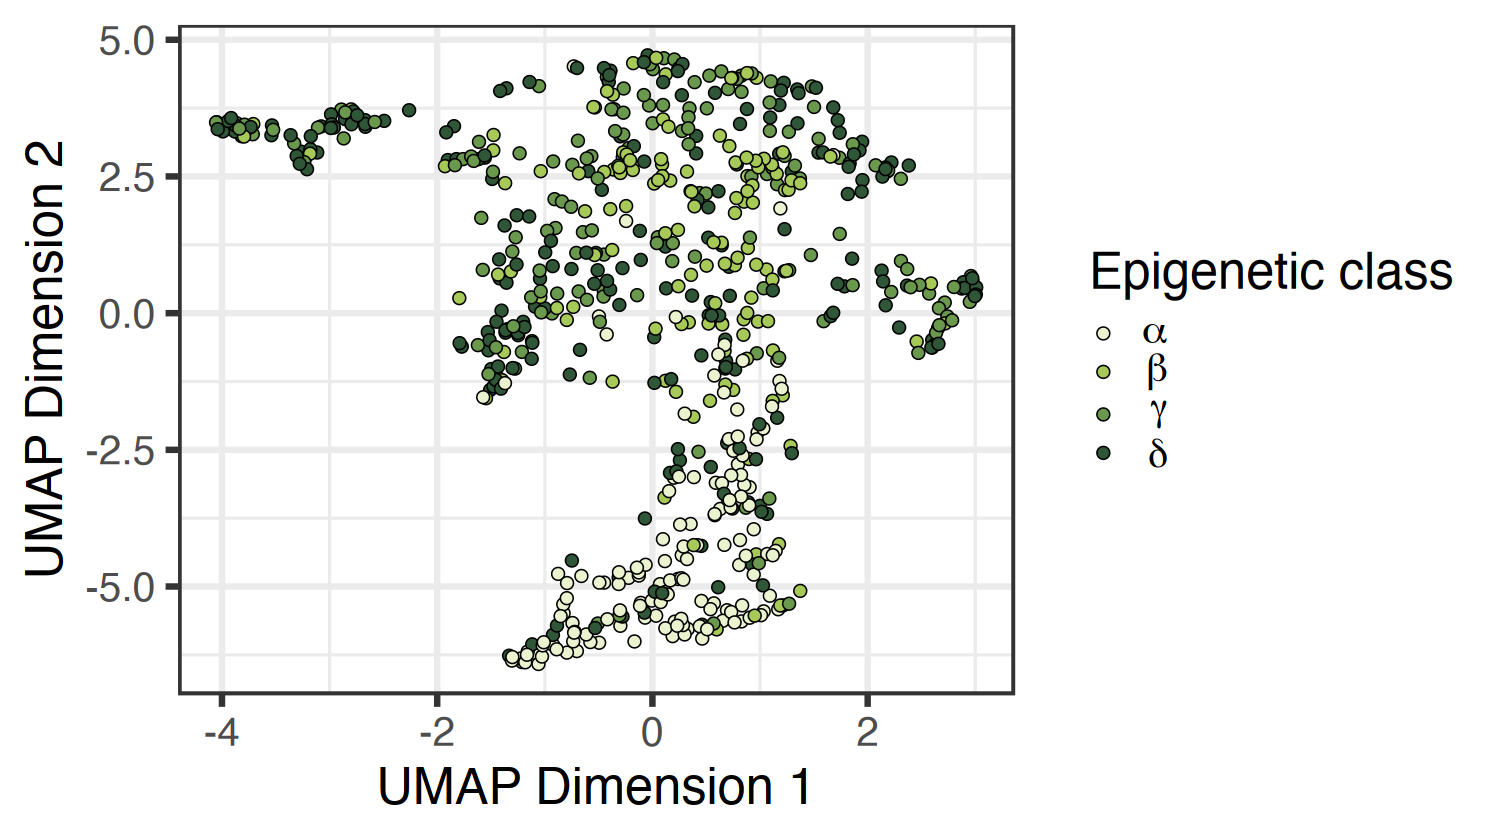

In [31]:
options(repr.plot.width=12.5, repr.plot.height=7)

p2 <- ggplot(plot_umap.1_df, aes(x = x, y = y, fill = factor(Epiclass))) +
  geom_point(size = 3, shape = 21, color ="black", alpha = 1) +
  scale_fill_manual(name = "Epigenetic class",
                    values = c("α" = "#ebf2cf",
                               "β" = "#a7c957",
                               "γ" = "#6a994e",
                               "δ" = "#2f5637"),
                    labels = c("α" = expression(alpha), "β" = expression(beta),
                               "γ" = expression(gamma),"δ" =expression(delta))) +
  #guides(fill = "none")+
  xlab("UMAP Dimension 1")+
  ylab("UMAP Dimension 2")+
  theme_bw(base_size = 30) 
p2


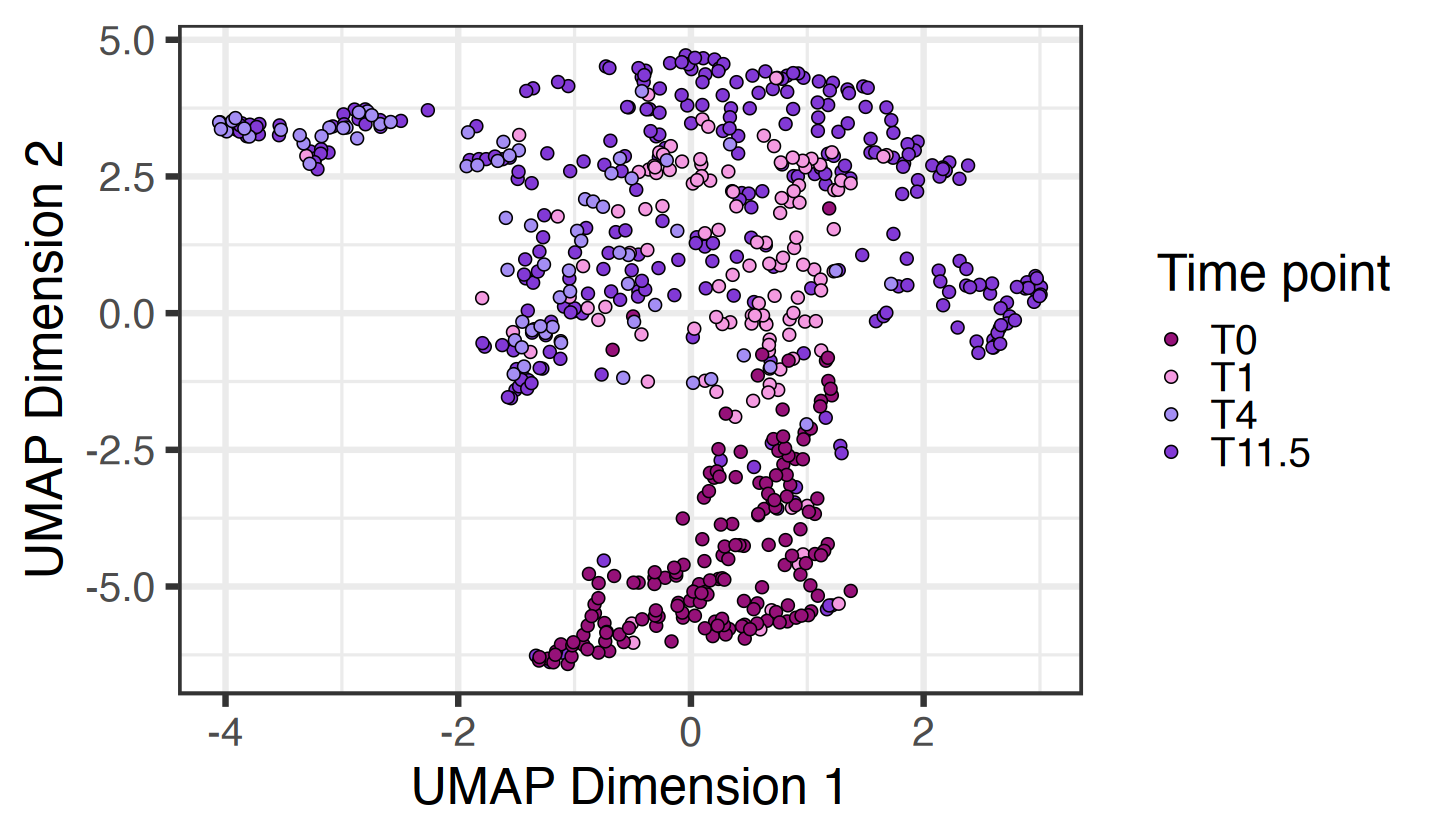

In [33]:
options(repr.plot.width=12, repr.plot.height=7)

p3 <- ggplot(plot_umap.1_df, aes(x = x, y = y, fill = Time)) +
  geom_point(size = 3, shape = 21, color ="black", alpha = 1) +
  scale_fill_manual(name = "Time point",
                    values =  c("T0" = "#961179",
                                "T1" =  "#F49AE1",
                                "T4" = "#A48EF4",
                                "T11.5"= "#8239D6")) +
  xlab("UMAP Dimension 1")+
  ylab("UMAP Dimension 2")+
  #guides(fill = "none")+
  theme_bw(base_size =30) 
p3


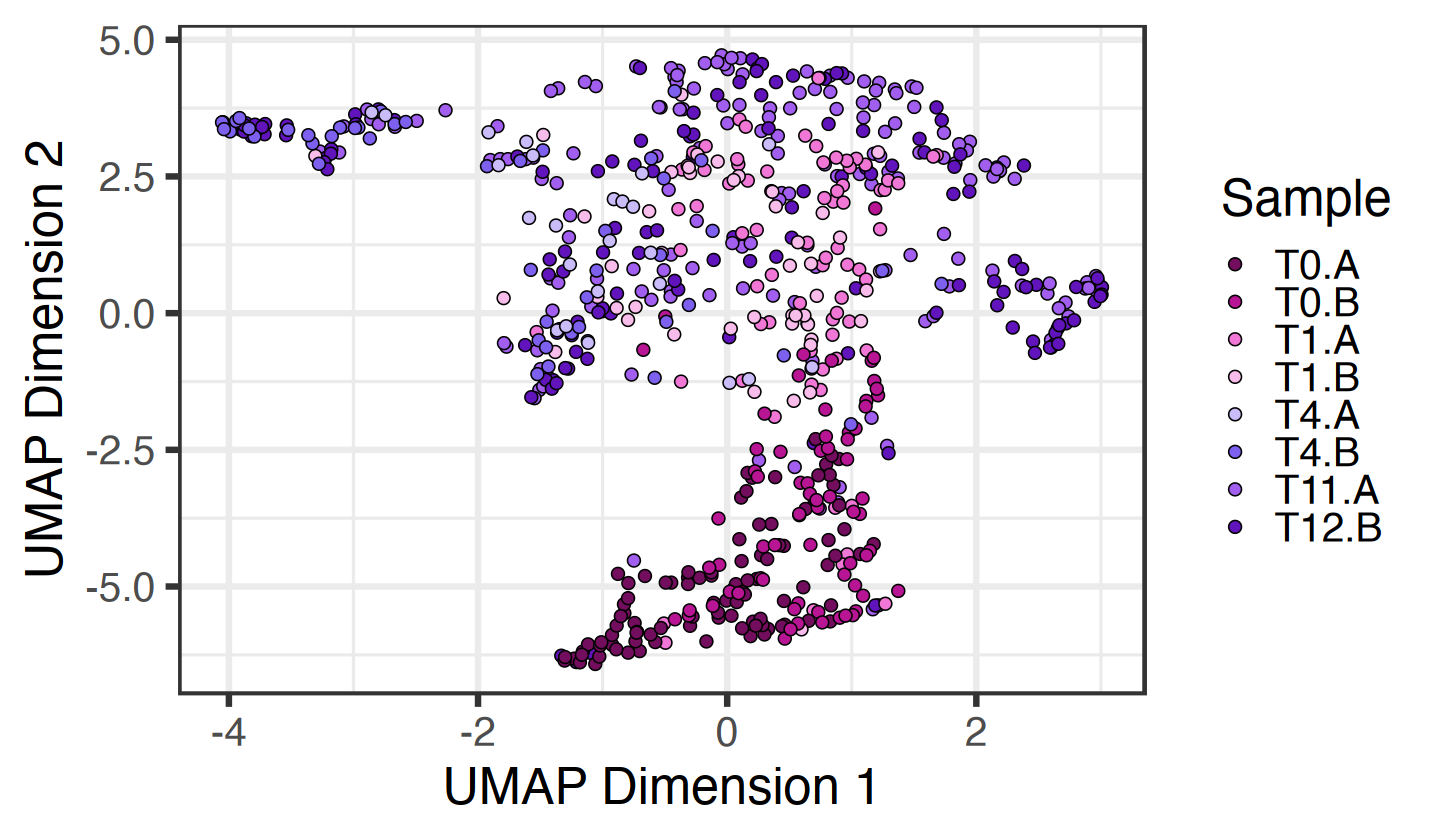

In [34]:
options(repr.plot.width=12, repr.plot.height=7)

p4 <- ggplot(plot_umap.1_df, aes(x = x, y = y, fill = Sample)) +
  geom_point(size = 3, shape = 21, color ="black", alpha = 1) +
  scale_fill_manual(name = "Sample",
                    values = c("T0.A" = "#730d5d",
                               "T0.B" = "#b81595",
                               "T1.A" =  "#f077d6",
                               "T1.B" =  "#f8bceb",
                               "T4.A" = "#c9bcf8",
                               "T4.B" = "#7e60ef",
                               "T11.A"= "#a25fef",
                               "T12.B"= "#6113bc")) +
  xlab("UMAP Dimension 1")+
  ylab("UMAP Dimension 2")+
  #guides(fill = "none")+
  theme_bw(base_size = 30) 
p4

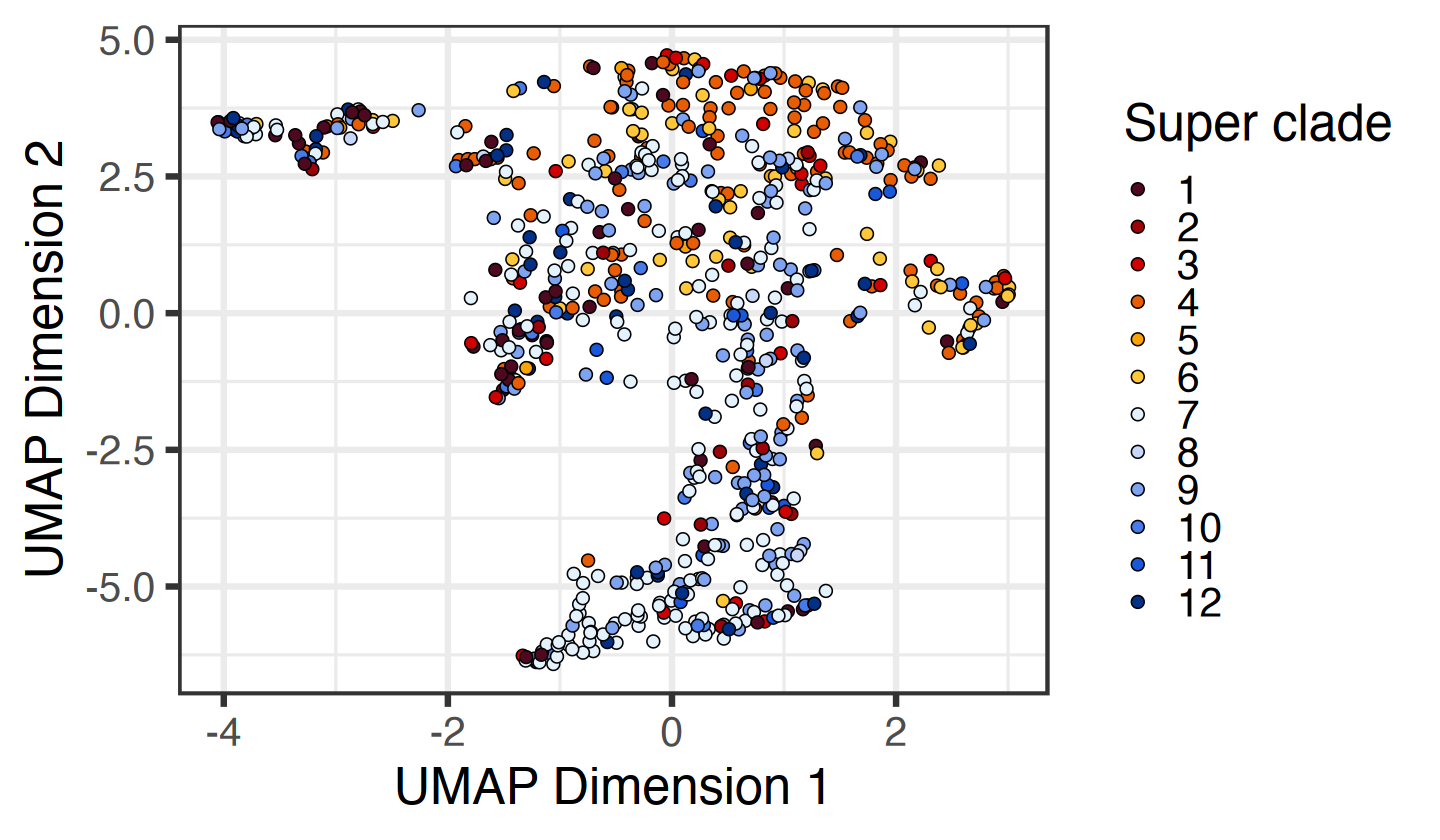

In [37]:
options(repr.plot.width=12, repr.plot.height=7)

p5 <- ggplot(plot_umap.1_df, aes(x = x, y = y, fill =Clade)) +
  geom_point(size = 3, shape = 21, color ="black", alpha = 1) +
  scale_fill_manual(name = "Super clade",
                    values = c("1" = "#4e0921",
                               "2" = "#9d0208",
                               "3" = "#d00000",
                               "4" = "#e85d04",
                               "5" = "#faa307",
                               "6" = "#ffc83b",
                               "7" = "#e3f2fd",
                               "8" = "#c8d7f9",
                               "9" = "#7ea3f1",
                               "10" = "#487bea",
                               "11" = "#1957db",
                               "12" = "#023087")) +
  xlab("UMAP Dimension 1")+
  ylab("UMAP Dimension 2")+
  #guides(fill = "none")+
  theme_bw(base_size = 30) 
p5